In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = '/content/drive/MyDrive/Equity'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
NOTEBOOKS_DIR = os.path.join(PROJECT_ROOT, 'notebooks')
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, 'outputs')
CHARTS_DIR = os.path.join(OUTPUTS_DIR, 'charts')

for folder in [PROJECT_ROOT, DATA_DIR, NOTEBOOKS_DIR, OUTPUTS_DIR, CHARTS_DIR]:
    os.makedirs(folder, exist_ok=True)

DB_PATH = os.path.join(DATA_DIR, 'equity_market.db')
print(f"Working inside: {PROJECT_ROOT}")

Clearing existing files in /content/drive before remounting.
Mounted at /content/drive
Working inside: /content/drive/MyDrive/Equity


In [ ]:
!pip install -q yfinance pandas numpy scipy scikit-learn xgboost shap matplotlib seaborn plotly streamlit anthropic fredapi

In [ ]:
import pandas as pd
import requests
import io

def fetch_nifty500_tickers():
    url = "https://nsearchives.nseindia.com/content/indices/ind_nifty500list.csv"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
        "Accept": "text/csv,application/csv",
        "Referer": "https://www.niftyindices.com/"
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        df = pd.read_csv(io.StringIO(response.text))
        df = df.rename(columns={"Symbol": "symbol", "Company Name": "company_name",
                                 "Industry": "sector"})
        print(f"Live NSE pull succeeded: {len(df)} tickers")
        return df[["symbol", "company_name", "sector"]]
    except Exception as e:
        print(f"Live NSE pull failed ({e}), falling back to curated list")
        return None

nifty500_df = fetch_nifty500_tickers()

Live NSE pull succeeded: 504 tickers


In [ ]:
CURATED_FALLBACK = [
    ("RELIANCE", "Reliance Industries", "Energy"),
    ("TCS", "Tata Consultancy Services", "IT"),
    ("HDFCBANK", "HDFC Bank", "Financial Services"),
    ("INFY", "Infosys", "IT"),
    ("ICICIBANK", "ICICI Bank", "Financial Services"),
    ("HINDUNILVR", "Hindustan Unilever", "FMCG"),
    ("ITC", "ITC Limited", "FMCG"),
    ("SBIN", "State Bank of India", "Financial Services"),
    ("BHARTIARTL", "Bharti Airtel", "Telecom"),
    ("KOTAKBANK", "Kotak Mahindra Bank", "Financial Services"),
    ("LT", "Larsen & Toubro", "Construction"),
    ("AXISBANK", "Axis Bank", "Financial Services"),
    ("ASIANPAINT", "Asian Paints", "Consumer Durables"),
    ("MARUTI", "Maruti Suzuki", "Auto"),
    ("SUNPHARMA", "Sun Pharmaceutical", "Pharma"),
    ("TITAN", "Titan Company", "Consumer Durables"),
    ("ULTRACEMCO", "UltraTech Cement", "Cement"),
    ("WIPRO", "Wipro", "IT"),
    ("NESTLEIND", "Nestle India", "FMCG"),
    ("HCLTECH", "HCL Technologies", "IT"),
]

if nifty500_df is None:
    nifty500_df = pd.DataFrame(CURATED_FALLBACK, columns=["symbol", "company_name", "sector"])
    print(f"Using curated fallback: {len(nifty500_df)} tickers")

nifty500_df.to_csv(os.path.join(DATA_DIR, "nifty500_tickers.csv"), index=False)

tickers = [t.strip() + ".NS" for t in nifty500_df["symbol"].tolist()]
print(f"Total tickers ready for ingestion: {len(tickers)}")
tickers[:5]

Total tickers ready for ingestion: 504


['360ONE.NS', '3MINDIA.NS', 'ABB.NS', 'ACC.NS', 'ACMESOLAR.NS']

In [ ]:
import logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

In [ ]:
import logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

import sqlite3

conn = sqlite3.connect(DB_PATH)

conn.execute("""
CREATE TABLE IF NOT EXISTS daily_prices (
    date TEXT,
    open REAL,
    high REAL,
    low REAL,
    close REAL,
    adj_close REAL,
    volume INTEGER,
    ticker TEXT
)
""")
conn.commit()

In [ ]:
import yfinance as yf
import time

tickers = [t.strip() + ".NS" for t in nifty500_df["symbol"].tolist()]

valid_tickers = []
dead_tickers = []

for i, ticker in enumerate(tickers):
    try:
        probe = yf.download(ticker, period="5d", progress=False, auto_adjust=False)
        if len(probe) > 0:
            valid_tickers.append(ticker)
        else:
            dead_tickers.append((ticker, "empty response"))
    except Exception as e:
        dead_tickers.append((ticker, str(e)))

    if (i + 1) % 50 == 0:
        print(f"Checked {i+1}/{len(tickers)}... valid so far: {len(valid_tickers)}")

    time.sleep(0.3)

print(f"\nValid tickers: {len(valid_tickers)}")
print(f"Dead tickers: {len(dead_tickers)}")

Checked 50/504... valid so far: 50
Checked 100/504... valid so far: 100
Checked 150/504... valid so far: 150
Checked 200/504... valid so far: 200
Checked 250/504... valid so far: 250
Checked 300/504... valid so far: 300
Checked 350/504... valid so far: 350
Checked 400/504... valid so far: 400
Checked 450/504... valid so far: 450
Checked 500/504... valid so far: 500

Valid tickers: 504
Dead tickers: 0


In [ ]:
valid_df = pd.DataFrame({"ticker": valid_tickers})
valid_df.to_csv(os.path.join(DATA_DIR, "valid_tickers.csv"), index=False)

dead_df = pd.DataFrame(dead_tickers, columns=["ticker", "reason"])
dead_df.to_csv(os.path.join(DATA_DIR, "dead_tickers.csv"), index=False)

print(f"Saved {len(valid_df)} valid tickers to disk")

Saved 504 valid tickers to disk


In [ ]:
print(f"DB_PATH: {DB_PATH}")
print(f"conn pointed at: {conn.execute('PRAGMA database_list').fetchall()}")

conn.close()
conn = sqlite3.connect(DB_PATH)

conn.execute("""
CREATE TABLE IF NOT EXISTS daily_prices (
    date TEXT,
    open REAL,
    high REAL,
    low REAL,
    close REAL,
    adj_close REAL,
    volume INTEGER,
    ticker TEXT
)
""")
conn.commit()

test_check = pd.read_sql("SELECT COUNT(*) AS rows FROM daily_prices", conn)
print(test_check)

DB_PATH: /content/drive/MyDrive/Equity/data/equity_market.db
conn pointed at: [(0, 'main', '/content/drive/MyDrive/Equity/data/equity_market.db')]
   rows
0     0


In [ ]:
import yfinance
print(yfinance.__version__)

0.2.66


In [ ]:
test = yf.download("RELIANCE.NS", start="2014-01-01", end="2024-12-31", progress=False, auto_adjust=False)
print(test.shape)
print(test.head())
print(test.columns.tolist())

(2710, 6)
Price        Adj Close       Close        High         Low        Open  \
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS   
Date                                                                     
2014-01-01  187.467316  203.164734  205.324844  202.890427  205.141968   
2014-01-02  184.556595  200.010284  204.810532  198.890228  202.913284   
2014-01-03  182.289200  197.553009  199.633118  195.438614  199.233093   
2014-01-06  180.327606  195.427185  197.324432  194.295700  197.061554   
2014-01-07  177.617249  192.489899  196.570099  192.021301  195.347183   

Price           Volume  
Ticker     RELIANCE.NS  
Date                    
2014-01-01     5849398  
2014-01-02     6023632  
2014-01-03    12833897  
2014-01-06    13315857  
2014-01-07    17311470  
[('Adj Close', 'RELIANCE.NS'), ('Close', 'RELIANCE.NS'), ('High', 'RELIANCE.NS'), ('Low', 'RELIANCE.NS'), ('Open', 'RELIANCE.NS'), ('Volume', 'RELIANCE.NS')]


In [ ]:
import logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)
import time

already_done = pd.read_sql("SELECT DISTINCT ticker FROM daily_prices", conn)["ticker"].tolist()
remaining = [t for t in valid_tickers if t.replace(".NS", "") not in already_done]
print(f"Already in DB: {len(already_done)} | Remaining to pull: {len(remaining)}")

failed = []
written_count = 0

for i, ticker in enumerate(remaining):
    try:
        df = yf.download(ticker, start="2014-01-01", end="2024-12-31",
                          progress=False, auto_adjust=False)

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        if len(df) > 100:
            df = df.reset_index()
            df.columns = [str(c).lower().replace(" ", "_") for c in df.columns]
            df["ticker"] = ticker.replace(".NS", "")
            df = df[["date", "open", "high", "low", "close", "adj_close", "volume", "ticker"]]
            df.to_sql("daily_prices", conn, if_exists="append", index=False)
            conn.commit()
            written_count += df.shape[0]
        else:
            failed.append((ticker, "insufficient history after listing"))
    except Exception as e:
        failed.append((ticker, str(e)))

    if (i + 1) % 50 == 0:
        live_count = pd.read_sql("SELECT COUNT(*) AS c FROM daily_prices", conn).iloc[0]["c"]
        print(f"Pulled {i+1}/{len(remaining)}... rows confirmed in DB: {live_count}")

    time.sleep(1.5)

final_check = pd.read_sql("SELECT COUNT(*) AS total_rows, COUNT(DISTINCT ticker) AS total_tickers FROM daily_prices", conn)
print(final_check)

Already in DB: 0 | Remaining to pull: 504
Pulled 50/504... rows confirmed in DB: 90101
Pulled 100/504... rows confirmed in DB: 196173
Pulled 150/504... rows confirmed in DB: 300019
Pulled 200/504... rows confirmed in DB: 408568
Pulled 250/504... rows confirmed in DB: 509591
Pulled 300/504... rows confirmed in DB: 605805
Pulled 350/504... rows confirmed in DB: 703625
Pulled 400/504... rows confirmed in DB: 796324
Pulled 450/504... rows confirmed in DB: 896566
Pulled 500/504... rows confirmed in DB: 998406
   total_rows  total_tickers
0     1009246            455


In [ ]:
failed_df = pd.DataFrame(failed, columns=["ticker", "reason"])
failed_df.to_csv(os.path.join(DATA_DIR, "failed_tickers.csv"), index=False)
print(f"Failed tickers: {len(failed_df)}")
failed_df["reason"].value_counts().head(10)

Failed tickers: 49


,count
reason,
insufficient history after listing,49


In [ ]:
metadata = nifty500_df.copy()
metadata = metadata.rename(columns={"symbol": "ticker"})

successful_tickers = pd.read_sql("SELECT DISTINCT ticker FROM daily_prices", conn)["ticker"].tolist()
metadata = metadata[metadata["ticker"].isin(successful_tickers)].reset_index(drop=True)

def assign_cap_band(rank, total):
    pct = rank / total
    if pct <= 0.20:
        return "Large"
    elif pct <= 0.60:
        return "Mid"
    else:
        return "Small"

metadata = metadata.reset_index().rename(columns={"index": "rank"})
metadata["market_cap_band"] = metadata["rank"].apply(lambda r: assign_cap_band(r, len(metadata)))
metadata = metadata.drop(columns=["rank"])

metadata.to_sql("stock_metadata", conn, if_exists="replace", index=False)
conn.commit()

print(f"stock_metadata rows: {len(metadata)}")
metadata.head(50)

stock_metadata rows: 455


,ticker,company_name,sector,market_cap_band
0,360ONE,360 ONE WAM Ltd.,Financial Services,Large
1,3MINDIA,3M India Ltd.,Diversified,Large
2,ABB,ABB India Ltd.,Capital Goods,Large
3,ACC,ACC Ltd.,Construction Materials,Large
4,AIAENG,AIA Engineering Ltd.,Capital Goods,Large
5,APLAPOLLO,APL Apollo Tubes Ltd.,Capital Goods,Large
6,AUBANK,AU Small Finance Bank Ltd.,Financial Services,Large
7,AWL,AWL Agri Business Ltd.,Fast Moving Consumer Goods,Large
8,AADHARHFC,Aadhar Housing Finance Ltd.,Financial Services,Large
9,AARTIIND,Aarti Industries Ltd.,Chemicals,Large


In [ ]:
conn.execute("CREATE INDEX IF NOT EXISTS idx_ticker_date ON daily_prices (ticker, date)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_date ON daily_prices (date)")
conn.commit()

print("Indexes created.")

Indexes created.


In [ ]:
checkpoint = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM daily_prices) AS total_price_rows,
        (SELECT COUNT(DISTINCT ticker) FROM daily_prices) AS distinct_tickers,
        (SELECT COUNT(*) FROM stock_metadata) AS metadata_rows,
        (SELECT MIN(date) FROM daily_prices) AS earliest_date,
        (SELECT MAX(date) FROM daily_prices) AS latest_date
""", conn)
checkpoint

,total_price_rows,distinct_tickers,metadata_rows,earliest_date,latest_date
0,1009246,455,455,2014-01-01 00:00:00,2024-12-30 00:00:00


In [ ]:
sample_join = pd.read_sql("""
    SELECT p.ticker, m.sector, m.market_cap_band, COUNT(*) AS rows_for_ticker
    FROM daily_prices p
    JOIN stock_metadata m ON p.ticker = m.ticker
    GROUP BY p.ticker
    LIMIT 5
""", conn)
sample_join

,ticker,sector,market_cap_band,rows_for_ticker
0,360ONE,Financial Services,Large,1306
1,3MINDIA,Diversified,Large,2710
2,AADHARHFC,Financial Services,Large,156
3,AARTIIND,Chemicals,Large,2710
4,AAVAS,Financial Services,Large,1537


In [ ]:
#Checking the distribution fo stocks among Mid, Small and Large.
band_check = pd.read_sql("""
    SELECT market_cap_band, COUNT(*) AS num_stocks
    FROM stock_metadata
    GROUP BY market_cap_band
    ORDER BY num_stocks DESC
""", conn)
band_check

,market_cap_band,num_stocks
0,Mid,182
1,Small,181
2,Large,92


In [ ]:
#Overview of the stocks;
query_1 = """
SELECT
    COUNT(DISTINCT ticker) AS total_stocks,
    MIN(date) AS earliest_date,
    MAX(date) AS latest_date,
    COUNT(*) AS total_observations,
    ROUND(AVG(volume), 0) AS avg_daily_volume
FROM daily_prices;
"""

result_1 = pd.read_sql(query_1, conn)
result_1

,total_stocks,earliest_date,latest_date,total_observations,avg_daily_volume
0,455,2014-01-01 00:00:00,2024-12-30 00:00:00,1009246,5055332.0


In [ ]:
#Scetor-Wise Annulaized Returns----Which sectors actually paid off?
query_2 = """
WITH first_last AS (
    SELECT
        p.ticker,
        m.sector,
        p.date,
        p.adj_close,
        ROW_NUMBER() OVER (PARTITION BY p.ticker ORDER BY p.date ASC) AS rn_first,
        ROW_NUMBER() OVER (PARTITION BY p.ticker ORDER BY p.date DESC) AS rn_last
    FROM daily_prices p
    JOIN stock_metadata m ON p.ticker = m.ticker
),
endpoints AS (
    SELECT
        ticker,
        sector,
        MAX(CASE WHEN rn_first = 1 THEN adj_close END) AS first_close,
        MAX(CASE WHEN rn_first = 1 THEN date END) AS first_date,
        MAX(CASE WHEN rn_last = 1 THEN adj_close END) AS last_close,
        MAX(CASE WHEN rn_last = 1 THEN date END) AS last_date
    FROM first_last
    WHERE rn_first = 1 OR rn_last = 1
    GROUP BY ticker, sector
),
with_years AS (
    SELECT
        ticker,
        sector,
        first_close,
        last_close,
        (JULIANDAY(last_date) - JULIANDAY(first_date)) / 365.25 AS years
    FROM endpoints
)
SELECT
    sector,
    COUNT(*) AS num_stocks,
    ROUND(AVG(POWER(last_close / first_close, 1.0 / years) - 1) * 100, 2) AS avg_annual_return_pct
FROM with_years
WHERE years > 5
GROUP BY sector
ORDER BY avg_annual_return_pct DESC;
"""

result_2 = pd.read_sql(query_2, conn)
result_2

,sector,num_stocks,avg_annual_return_pct
0,Chemicals,21,32.68
1,Capital Goods,47,32.33
2,Construction,12,31.35
3,Textiles,5,31.33
4,Information Technology,20,29.45
5,Automobile and Auto Components,30,27.21
6,Consumer Services,12,26.74
7,Consumer Durables,14,26.24
8,Realty,9,26.01
9,Power,15,23.26


In [ ]:
with open(os.path.join(DATA_DIR, "queries.sql"), "a") as f:
    f.write("""
-- Q1: Stock overview
-- Business purpose: Brief view of the overall financial landscape
SELECT
    COUNT(DISTINCT ticker) AS total_stocks,
    MIN(date) AS earliest_date,
    MAX(date) AS latest_date,
    COUNT(*) AS total_observations,
    ROUND(AVG(volume), 0) AS avg_daily_volume
FROM daily_prices;

-- Q2: Sector-wise CAGR using actual first/last observed price per ticker
-- Business purpose: Sector allocation decisions

WITH first_last AS (
    SELECT
        p.ticker,
        m.sector,
        p.date,
        p.adj_close,
        ROW_NUMBER() OVER (PARTITION BY p.ticker ORDER BY p.date ASC) AS rn_first,
        ROW_NUMBER() OVER (PARTITION BY p.ticker ORDER BY p.date DESC) AS rn_last
    FROM daily_prices p
    JOIN stock_metadata m ON p.ticker = m.ticker
),
endpoints AS (
    SELECT
        ticker,
        sector,
        MAX(CASE WHEN rn_first = 1 THEN adj_close END) AS first_close,
        MAX(CASE WHEN rn_first = 1 THEN date END) AS first_date,
        MAX(CASE WHEN rn_last = 1 THEN adj_close END) AS last_close,
        MAX(CASE WHEN rn_last = 1 THEN date END) AS last_date
    FROM first_last
    WHERE rn_first = 1 OR rn_last = 1
    GROUP BY ticker, sector
),
with_years AS (
    SELECT
        ticker,
        sector,
        first_close,
        last_close,
        (JULIANDAY(last_date) - JULIANDAY(first_date)) / 365.25 AS years
    FROM endpoints
)
SELECT
    sector,
    COUNT(*) AS num_stocks,
    ROUND(AVG(POWER(last_close / first_close, 1.0 / years) - 1) * 100, 2) AS avg_annual_return_pct
FROM with_years
WHERE years > 5
GROUP BY sector
ORDER BY avg_annual_return_pct DESC;
""")

print("Q1 and Q2 written to queries.sql")

Q1 and Q2 written to queries.sql


In [ ]:
query_3 = """
WITH recent AS (
    SELECT ticker, date, adj_close,
           LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
    FROM daily_prices
    WHERE date >= DATE((SELECT MAX(date) FROM daily_prices), '-1 year')
),
daily_ret AS (
    SELECT ticker,
           (adj_close / prev_close - 1) AS ret
    FROM recent
    WHERE prev_close IS NOT NULL
)
SELECT ticker,
       ROUND(AVG(ret) * 252 * 100, 2) AS annualized_return_pct,
       ROUND(SQRT(AVG(ret * ret) - AVG(ret) * AVG(ret)) * SQRT(252) * 100, 2) AS annualized_vol_pct,
       COUNT(*) AS trading_days
FROM daily_ret
GROUP BY ticker
HAVING trading_days > 200
ORDER BY annualized_vol_pct DESC
LIMIT 10;
"""

result_3 = pd.read_sql(query_3, conn)
result_3

,ticker,annualized_return_pct,annualized_vol_pct,trading_days
0,IFCI,97.76,71.10,244
1,FORCEMOT,95.84,64.99,219
2,GRSE,86.76,64.97,244
3,COCHINSHIP,107.54,64.60,244
4,PAYTM,68.55,64.47,244
5,ITI,41.32,63.71,244
6,RVNL,103.25,63.08,244
7,MAZDOCK,90.93,62.70,244
8,HUDCO,78.64,62.03,244
9,GODFRYPHLP,106.28,61.41,244


In [ ]:
with open(os.path.join(DATA_DIR, "queries.sql"), "a") as f:
    f.write("""
-- Q3: Top 10 most volatile stocks, for 1 year time-frame
-- Business purpose: Risk monitoring, position sizing

WITH recent AS (
    SELECT ticker, date, adj_close,
           LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
    FROM daily_prices
    WHERE date >= DATE((SELECT MAX(date) FROM daily_prices), '-1 year')
),
daily_ret AS (
    SELECT ticker,
           (adj_close / prev_close - 1) AS ret
    FROM recent
    WHERE prev_close IS NOT NULL
)
SELECT ticker,
       ROUND(AVG(ret) * 252 * 100, 2) AS annualized_return_pct,
       ROUND(SQRT(AVG(ret * ret) - AVG(ret) * AVG(ret)) * SQRT(252) * 100, 2) AS annualized_vol_pct,
       COUNT(*) AS trading_days
FROM daily_ret
GROUP BY ticker
HAVING trading_days > 200
ORDER BY annualized_vol_pct DESC
LIMIT 10;
""")
print("Q3 written to queries.sql")

Q3 written to queries.sql


In [ ]:
#Maximum Drawdowns
query_4 = """
WITH peaks AS (
    SELECT ticker, date, adj_close,
           MAX(adj_close) OVER (
               PARTITION BY ticker
               ORDER BY date
               ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
           ) AS running_peak
    FROM daily_prices
)
SELECT ticker,
       ROUND(MIN((adj_close / running_peak - 1) * 100), 2) AS max_drawdown_pct
FROM peaks
GROUP BY ticker
ORDER BY max_drawdown_pct ASC
LIMIT 20;
"""

result_4 = pd.read_sql(query_4, conn)
result_4

,ticker,max_drawdown_pct
0,PATANJALI,-99.65
1,RPOWER,-99.04
2,JPPOWER,-98.45
3,IDEA,-97.56
4,YESBANK,-97.22
5,INOXWIND,-96.44
6,SUZLON,-95.16
7,CGPOWER,-94.99
8,PGEL,-94.13
9,J&KBANK,-93.80


In [ ]:
#Patanjali's Analmoly
patanjali_check = pd.read_sql("""
    SELECT date, adj_close, volume
    FROM daily_prices
    WHERE ticker = 'PATANJALI'
    ORDER BY date ASC
    LIMIT 5
""", conn)
print(patanjali_check)

patanjali_check_end = pd.read_sql("""
    SELECT date, adj_close, volume
    FROM daily_prices
    WHERE ticker = 'PATANJALI'
    ORDER BY date DESC
    LIMIT 5
""", conn)
print(patanjali_check_end)

patanjali_trough = pd.read_sql("""
    WITH peaks AS (
        SELECT date, adj_close,
               MAX(adj_close) OVER (ORDER BY date ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS running_peak
        FROM daily_prices
        WHERE ticker = 'PATANJALI'
    )
    SELECT date, adj_close, running_peak,
           ROUND((adj_close / running_peak - 1) * 100, 2) AS drawdown_pct
    FROM peaks
    ORDER BY drawdown_pct ASC
    LIMIT 1
""", conn)
patanjali_trough

                  date    adj_close  volume
0  2014-01-01 00:00:00  1230.324219   13295
1  2014-01-02 00:00:00  1151.312500    8907
2  2014-01-03 00:00:00  1156.150024    6426
3  2014-01-06 00:00:00  1128.737793    4700
4  2014-01-07 00:00:00  1233.549316   23977
                  date   adj_close   volume
0  2024-12-30 00:00:00  586.658508   418839
1  2024-12-27 00:00:00  578.307434  1860681
2  2024-12-26 00:00:00  568.964172  2879901
3  2024-12-24 00:00:00  574.322083  1109139
4  2024-12-23 00:00:00  576.901794  1001769


,date,adj_close,running_peak,drawdown_pct
0,2020-01-27 00:00:00,5.528337,1585.070312,-99.65


In [ ]:
with open(os.path.join(DATA_DIR, "queries.sql"), "a") as f:
    f.write("""
-- Q4: Maximum drawdown per stock (worst peak-to-trough decline)
-- Business purpose: Tail risk assessment
-- Note: drawdowns reflect full ticker history including pre-corporate-action
-- periods. E.g. PATANJALI shows -99.65% because the ticker's history includes
-- the 2017-2019 Ruchi Soya insolvency (trough: 2020-01-27, price fell from a
-- running peak of ~1585 to ~5.53) prior to the Patanjali Ayurved acquisition
-- and rename. The figure is mathematically correct but spans what was
-- effectively a different corporate entity than the current business.
WITH peaks AS (
    SELECT ticker, date, adj_close,
           MAX(adj_close) OVER (
               PARTITION BY ticker
               ORDER BY date
               ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
           ) AS running_peak
    FROM daily_prices
)
SELECT ticker,
       ROUND(MIN((adj_close / running_peak - 1) * 100), 2) AS max_drawdown_pct
FROM peaks
GROUP BY ticker
ORDER BY max_drawdown_pct ASC
LIMIT 20;
""")
print("Q4 written to queries.sql")

Q4 written to queries.sql


In [ ]:
vix_test = yf.download("^INDIAVIX", start="2014-01-01", end="2024-12-31", progress=False, auto_adjust=False)
print(vix_test.shape)
print(vix_test.head())

(2692, 6)
Price       Adj Close      Close       High       Low       Open    Volume
Ticker      ^INDIAVIX  ^INDIAVIX  ^INDIAVIX ^INDIAVIX  ^INDIAVIX ^INDIAVIX
Date                                                                      
2014-01-01  15.580000  15.580000  15.580000     15.10  15.120000         0
2014-01-02  16.549999  16.549999  16.969999     15.33  15.580000         0
2014-01-03  15.870000  15.870000  17.320000     15.79  16.549999         0
2014-01-06  16.500000  16.500000  16.910000     15.87  15.870000         0
2014-01-07  16.320000  16.320000  16.910000     16.10  16.500000         0


In [ ]:
if isinstance(vix_test.columns, pd.MultiIndex):
    vix_test.columns = vix_test.columns.get_level_values(0)

vix_df = vix_test.reset_index()
vix_df.columns = [str(c).lower().replace(" ", "_") for c in vix_df.columns]
vix_df = vix_df[["date", "close"]].rename(columns={"close": "vix_close"})

vix_df.to_sql("india_vix", conn, if_exists="replace", index=False)
conn.commit()

print(f"india_vix rows: {len(vix_df)}")
vix_df.head()

india_vix rows: 2692


,date,vix_close
0,2014-01-01,15.580000
1,2014-01-02,16.549999
2,2014-01-03,15.870000
3,2014-01-06,16.500000
4,2014-01-07,16.320000


In [ ]:
# Mrkt Retrn vs VIX

query_5 = """
SELECT
    p.date,
    AVG(p.daily_ret) AS market_daily_ret,
    v.vix_close,
    v.vix_close - LAG(v.vix_close) OVER (ORDER BY v.date) AS vix_change
FROM (
    SELECT date, ticker,
           (adj_close / LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) - 1) AS daily_ret
    FROM daily_prices
) p
JOIN india_vix v ON p.date = v.date
WHERE p.daily_ret IS NOT NULL
GROUP BY p.date, v.vix_close
"""

result_5 = pd.read_sql(query_5, conn)
result_5[["market_daily_ret", "vix_close", "vix_change"]].corr()

,market_daily_ret,vix_close,vix_change
market_daily_ret,1.000000,-0.088970,-0.556848
vix_close,-0.088970,1.000000,0.090754
vix_change,-0.556848,0.090754,1.000000


In [ ]:

with open(os.path.join(DATA_DIR, "queries.sql"), "a") as f:
    f.write("""
-- Q5: Market return vs. India VIX relationship
-- Business purpose: Validate the well-known inverse vol-return relationship
-- and identify the extent to whoch it actually holds in this data.

SELECT
    p.date,
    AVG(p.daily_ret) AS market_daily_ret,
    v.vix_close,
    v.vix_close - LAG(v.vix_close) OVER (ORDER BY v.date) AS vix_change
FROM (
    SELECT date, ticker,
           (adj_close / LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) - 1) AS daily_ret
    FROM daily_prices
) p
JOIN india_vix v ON p.date = v.date
WHERE p.daily_ret IS NOT NULL
GROUP BY p.date, v.vix_close;
""")
print("Q5 written to queries.sql")

Q5 written to queries.sql


In [ ]:
query_6 = """
SELECT
    ticker,
    ROUND(AVG(close * volume), 0) AS avg_daily_turnover,
    COUNT(*) AS trading_days
FROM daily_prices
GROUP BY ticker
HAVING trading_days > 500
ORDER BY avg_daily_turnover DESC
LIMIT 20;
"""

result_6 = pd.read_sql(query_6, conn)
result_6

,ticker,avg_daily_turnover,trading_days
0,RELIANCE,1.239189e+10,2710
1,HDFCBANK,1.073919e+10,2710
2,ICICIBANK,9.161196e+09,2710
3,SBIN,8.275055e+09,2710
4,ETERNAL,7.468161e+09,849
5,INFY,7.303291e+09,2710
6,AXISBANK,7.062330e+09,2710
7,TMPV,6.758763e+09,2710
8,BAJFINANCE,6.186235e+09,2710
9,TCS,6.017796e+09,2710


In [ ]:
query_7 = """
WITH ranked AS (
    SELECT
        ticker,
        date,
        adj_close,
        MAX(adj_close) OVER (
            PARTITION BY ticker
            ORDER BY date
            ROWS BETWEEN 251 PRECEDING AND CURRENT ROW
        ) AS rolling_52wk_high,
        MIN(adj_close) OVER (
            PARTITION BY ticker
            ORDER BY date
            ROWS BETWEEN 251 PRECEDING AND CURRENT ROW
        ) AS rolling_52wk_low,
        ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY date DESC) AS rn
    FROM daily_prices
)
SELECT
    ticker,
    date AS as_of_date,
    ROUND(adj_close, 2) AS current_price,
    ROUND(rolling_52wk_high, 2) AS week52_high,
    ROUND(rolling_52wk_low, 2) AS week52_low,
    ROUND((adj_close / rolling_52wk_high - 1) * 100, 2) AS pct_below_52wk_high
FROM ranked
WHERE rn = 1
ORDER BY pct_below_52wk_high DESC
LIMIT 20;
"""

result_7 = pd.read_sql(query_7, conn)
result_7

,ticker,as_of_date,current_price,week52_high,week52_low,pct_below_52wk_high
0,360ONE,2024-12-30 00:00:00,1249.55,1249.55,590.62,0.00
1,ABDL,2024-12-30 00:00:00,420.84,420.84,283.49,0.00
2,ASTERDM,2024-12-30 00:00:00,511.57,511.57,291.83,0.00
3,BAJAJHLDNG,2024-12-30 00:00:00,12543.26,12543.26,7556.89,0.00
4,COFORGE,2024-12-30 00:00:00,1941.10,1941.10,842.20,0.00
5,COROMANDEL,2024-12-30 00:00:00,1848.64,1848.64,1024.41,0.00
6,CRISIL,2024-12-30 00:00:00,5860.83,5860.83,3688.97,0.00
7,FORTIS,2024-12-30 00:00:00,724.94,724.94,379.57,0.00
8,INDHOTEL,2024-12-30 00:00:00,887.04,887.04,421.74,0.00
9,INDIACEM,2024-12-30 00:00:00,380.45,380.45,184.70,0.00


In [ ]:
query_8 = """
WITH daily_returns AS (
    SELECT
        p.date,
        p.ticker,
        m.sector,
        (p.adj_close / LAG(p.adj_close) OVER (PARTITION BY p.ticker ORDER BY p.date) - 1) AS daily_ret
    FROM daily_prices p
    JOIN stock_metadata m ON p.ticker = m.ticker
)
SELECT
    sector,
    strftime('%Y', date) AS year,
    ROUND(AVG(daily_ret) * 100, 3) AS avg_monthly_return_pct
FROM daily_returns
WHERE daily_ret IS NOT NULL
GROUP BY sector, year
ORDER BY year, sector;
"""

result_8 = pd.read_sql(query_8, conn)
print(result_8.shape)
result_8.head(10)

(220, 3)


,sector,year,avg_monthly_return_pct
0,Automobile and Auto Components,2014,0.410
1,Capital Goods,2014,0.312
2,Chemicals,2014,0.292
3,Construction,2014,0.450
4,Construction Materials,2014,0.232
5,Consumer Durables,2014,0.215
6,Consumer Services,2014,0.210
7,Diversified,2014,0.268
8,Fast Moving Consumer Goods,2014,0.155
9,Financial Services,2014,0.252


In [ ]:
with open(os.path.join(DATA_DIR, "queries.sql"), "a") as f:
    f.write("""
-- Q6: Highest average daily turnover (price x volume)
-- Business purpose: Liquidity screening for position sizing
SELECT
    ticker,
    ROUND(AVG(close * volume), 0) AS avg_daily_turnover,
    COUNT(*) AS trading_days
FROM daily_prices
GROUP BY ticker
HAVING trading_days > 500
ORDER BY avg_daily_turnover DESC
LIMIT 20;

-- Q7: 52-week high/low proximity (as of latest date in dataset)
-- Business purpose: Standard screener metric for momentum/breakout signals
WITH ranked AS (
    SELECT
        ticker, date, adj_close,
        MAX(adj_close) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 251 PRECEDING AND CURRENT ROW) AS rolling_52wk_high,
        MIN(adj_close) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 251 PRECEDING AND CURRENT ROW) AS rolling_52wk_low,
        ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY date DESC) AS rn
    FROM daily_prices
)
SELECT
    ticker, date AS as_of_date, ROUND(adj_close, 2) AS current_price,
    ROUND(rolling_52wk_high, 2) AS week52_high, ROUND(rolling_52wk_low, 2) AS week52_low,
    ROUND((adj_close / rolling_52wk_high - 1) * 100, 2) AS pct_below_52wk_high
FROM ranked
WHERE rn = 1
ORDER BY pct_below_52wk_high DESC
LIMIT 20;

-- Q8: Sector rotation data, average return by sector by year
-- Business purpose: Identify which sectors led/lagged in which years
SELECT
    m.sector,
    strftime('%Y', p.date) AS year,
    ROUND(AVG((p.adj_close / LAG(p.adj_close) OVER (PARTITION BY p.ticker ORDER BY p.date) - 1)) * 100, 3) AS avg_monthly_return_pct
FROM daily_prices p
JOIN stock_metadata m ON p.ticker = m.ticker
GROUP BY m.sector, year
ORDER BY year, m.sector;
""")
print("Q6, Q7, Q8 written to queries.sql")

Q6, Q7, Q8 written to queries.sql


In [ ]:
nifty50_test = yf.download("^NSEI", start="2014-01-01", end="2024-12-31", progress=False, auto_adjust=False)

if isinstance(nifty50_test.columns, pd.MultiIndex):
    nifty50_test.columns = nifty50_test.columns.get_level_values(0)

print(nifty50_test.shape)

nifty50_df = nifty50_test.reset_index()
nifty50_df.columns = [str(c).lower().replace(" ", "_") for c in nifty50_df.columns]
nifty50_df["ticker"] = "NIFTY_50"
nifty50_df = nifty50_df[["date", "open", "high", "low", "close", "adj_close", "volume", "ticker"]]

nifty50_df.to_sql("daily_prices", conn, if_exists="append", index=False)
conn.commit()

check = pd.read_sql("SELECT COUNT(*) AS rows FROM daily_prices WHERE ticker = 'NIFTY_50'", conn)
print(check)

(2698, 6)
   rows
0  2698


In [ ]:
query_9 = """
WITH daily_pct_moves AS (
    SELECT
        ticker,
        date,
        (adj_close / LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) - 1) * 100 AS pct_move
    FROM daily_prices
    WHERE ticker != 'NIFTY_50'
)
SELECT * FROM (
    SELECT ticker, date, ROUND(pct_move, 2) AS pct_move, 'TOP' AS category
    FROM daily_pct_moves
    WHERE pct_move IS NOT NULL
    ORDER BY pct_move DESC
    LIMIT 10
)
UNION ALL
SELECT * FROM (
    SELECT ticker, date, ROUND(pct_move, 2) AS pct_move, 'BOTTOM' AS category
    FROM daily_pct_moves
    WHERE pct_move IS NOT NULL
    ORDER BY pct_move ASC
    LIMIT 10
);
"""

result_9 = pd.read_sql(query_9, conn)
result_9

,ticker,date,pct_move,category
0,INDIAMART,2019-10-27 00:00:00,104.06,TOP
1,INDIAMART,2020-11-14 00:00:00,99.40,TOP
2,YESBANK,2020-03-17 00:00:00,58.09,TOP
3,PNB,2017-10-25 00:00:00,46.20,TOP
4,YESBANK,2020-03-16 00:00:00,45.21,TOP
5,INDUSINDBK,2020-03-26 00:00:00,44.67,TOP
6,IDEA,2020-02-19 00:00:00,40.00,TOP
7,ZEEL,2021-09-14 00:00:00,39.98,TOP
8,BANDHANBNK,2020-03-26 00:00:00,39.32,TOP
9,CANBK,2017-10-25 00:00:00,38.73,TOP


In [ ]:
beta_query = """
WITH stock_returns AS (
    SELECT
        ticker,
        date,
        (adj_close / LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) - 1) AS stock_ret
    FROM daily_prices
    WHERE ticker != 'NIFTY_50'
),
market_returns AS (
    SELECT
        date,
        (adj_close / LAG(adj_close) OVER (ORDER BY date) - 1) AS market_ret
    FROM daily_prices
    WHERE ticker = 'NIFTY_50'
),
joined AS (
    SELECT s.ticker, s.date, s.stock_ret, m.market_ret
    FROM stock_returns s
    JOIN market_returns m ON s.date = m.date
    WHERE s.stock_ret IS NOT NULL AND m.market_ret IS NOT NULL
),
rolling_stats AS (
    SELECT
        ticker,
        date,
        stock_ret,
        market_ret,
        AVG(stock_ret) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 89 PRECEDING AND CURRENT ROW) AS avg_stock_ret,
        AVG(market_ret) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 89 PRECEDING AND CURRENT ROW) AS avg_market_ret,
        AVG(market_ret * market_ret) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 89 PRECEDING AND CURRENT ROW) AS avg_market_ret_sq,
        AVG(stock_ret * market_ret) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 89 PRECEDING AND CURRENT ROW) AS avg_cross,
        ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY date DESC) AS rn
    FROM joined
)
SELECT
    ticker,
    date AS as_of_date,
    ROUND(
        (avg_cross - avg_stock_ret * avg_market_ret) /
        (avg_market_ret_sq - avg_market_ret * avg_market_ret),
        3
    ) AS rolling_90d_beta
FROM rolling_stats
WHERE rn = 1
ORDER BY rolling_90d_beta DESC
LIMIT 20;
"""

result_10 = pd.read_sql(beta_query, conn)
result_10

,ticker,as_of_date,rolling_90d_beta
0,DLF,2024-12-30 00:00:00,1.877
1,BHEL,2024-12-30 00:00:00,1.861
2,SCI,2024-12-30 00:00:00,1.836
3,SWANCORP,2024-12-30 00:00:00,1.745
4,PFC,2024-12-30 00:00:00,1.720
5,ENGINERSIN,2024-12-30 00:00:00,1.718
6,IRB,2024-12-30 00:00:00,1.708
7,ADANIPORTS,2024-12-30 00:00:00,1.703
8,HUDCO,2024-12-30 00:00:00,1.684
9,SCHNEIDER,2024-12-30 00:00:00,1.681


In [ ]:
split_check = pd.read_sql("""
    SELECT ticker, date, adj_close, volume
    FROM daily_prices
    WHERE ticker IN ('GPIL', 'CGCL', 'MOTILALOFS')
    AND date BETWEEN '2023-12-28' AND '2024-01-03'
    ORDER BY ticker, date
""", conn)
split_check
############
affected_check = pd.read_sql("""
    SELECT ticker FROM (
        SELECT ticker, ROUND(MIN((adj_close / running_peak - 1) * 100), 2) AS dd
        FROM (
            SELECT ticker, date, adj_close,
                   MAX(adj_close) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS running_peak
            FROM daily_prices
        )
        GROUP BY ticker
        ORDER BY dd ASC
        LIMIT 20
    )
    WHERE ticker IN ('GPIL', 'CGCL', 'MOTILALOFS')
""", conn)
print(f"Affected tickers in Q4 top-20: {len(affected_check)}")

Affected tickers in Q4 top-20: 0


In [ ]:
with open(os.path.join(DATA_DIR, "queries.sql"), "a") as f:
    f.write("""
-- Q9: Best and worst single-day moves across the database.
-- Business purpose: Identify extreme single-day events, cross-checked against
-- known market history (PSU bank recap Oct 2017, COVID crash/bounce Mar 2020).

WITH daily_moves AS (
    SELECT ticker, date,
           (adj_close / LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) - 1) * 100 AS pct_move
    FROM daily_prices
    WHERE ticker != 'NIFTY_50'
)
SELECT ticker, date, ROUND(pct_move, 2) AS pct_move, 'TOP' AS category
FROM daily_moves WHERE pct_move IS NOT NULL ORDER BY pct_move DESC LIMIT 10
UNION ALL
SELECT ticker, date, ROUND(pct_move, 2) AS pct_move, 'BOTTOM' AS category
FROM daily_moves WHERE pct_move IS NOT NULL ORDER BY pct_move ASC LIMIT 10;

-- Q10: Rolling 90-day beta of each stock vs NIFTY 50
-- Business purpose: Systematic risk measurement; identifies which stocks
-- amplify (beta > 1) or dampen (beta < 1) market-wide moves.

-- Note: beta shown is a single snapshot as of the last date in the dataset
-- (2024-12-30) using a trailing 90-day window; beta is not static and shifts
-- across different windows, so this should be taken as "beta at that point in
-- time," not a permanent stock characteristic.

WITH stock_returns AS (
    SELECT ticker, date,
           (adj_close / LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) - 1) AS stock_ret
    FROM daily_prices WHERE ticker != 'NIFTY_50'
),
market_returns AS (
    SELECT date, (adj_close / LAG(adj_close) OVER (ORDER BY date) - 1) AS market_ret
    FROM daily_prices WHERE ticker = 'NIFTY_50'
),
joined AS (
    SELECT s.ticker, s.date, s.stock_ret, m.market_ret
    FROM stock_returns s JOIN market_returns m ON s.date = m.date
    WHERE s.stock_ret IS NOT NULL AND m.market_ret IS NOT NULL
),
rolling_stats AS (
    SELECT ticker, date, stock_ret, market_ret,
           AVG(stock_ret) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 89 PRECEDING AND CURRENT ROW) AS avg_stock_ret,
           AVG(market_ret) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 89 PRECEDING AND CURRENT ROW) AS avg_market_ret,
           AVG(market_ret * market_ret) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 89 PRECEDING AND CURRENT ROW) AS avg_market_ret_sq,
           AVG(stock_ret * market_ret) OVER (PARTITION BY ticker ORDER BY date ROWS BETWEEN 89 PRECEDING AND CURRENT ROW) AS avg_cross,
           ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY date DESC) AS rn
    FROM joined
)
SELECT ticker, date AS as_of_date,
       ROUND((avg_cross - avg_stock_ret * avg_market_ret) / (avg_market_ret_sq - avg_market_ret * avg_market_ret), 3) AS rolling_90d_beta
FROM rolling_stats
WHERE rn = 1
ORDER BY rolling_90d_beta DESC
LIMIT 20;
""")
print("Q9 and Q10 written to queries.sql")

Q9 and Q10 written to queries.sql


In [ ]:
from google.colab import userdata
import os

os.environ["FRED_API_KEY"] = userdata.get("FRED_API_KEY").strip() #
from fredapi import Fred

fred = Fred(api_key=os.environ.get("FRED_API_KEY"))

fedfunds = fred.get_series("FEDFUNDS", observation_start="2014-01-01")
fedfunds = fedfunds.resample("M").mean().reset_index()
fedfunds.columns = ["date", "fed_funds_rate"]

fedfunds.to_sql("macro_indicators", conn, if_exists="replace", index=False)
conn.commit()

print(f"macro_indicators rows: {len(fedfunds)}")
fedfunds.head()

macro_indicators rows: 149


/tmp/ipykernel_1702/997461365.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fedfunds = fedfunds.resample("M").mean().reset_index()


,date,fed_funds_rate
0,2014-01-31,0.07
1,2014-02-28,0.07
2,2014-03-31,0.08
3,2014-04-30,0.09
4,2014-05-31,0.09


In [ ]:
import sqlite3
import os


view = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM daily_prices WHERE ticker = 'NIFTY_50') AS nifty50_rows,
        (SELECT COUNT(*) FROM india_vix) AS vix_rows,
        (SELECT COUNT(*) FROM macro_indicators) AS macro_rows,
        (SELECT COUNT(DISTINCT ticker) FROM daily_prices) AS total_distinct_tickers
""", conn)
view

,nifty50_rows,vix_rows,macro_rows,total_distinct_tickers
0,2698,2692,149,456


In [ ]:
import pandas as pd
import numpy as np
import sqlite3

# Ensure conn is defined for this cell
conn = sqlite3.connect(DB_PATH)

returnq = """
SELECT ticker, date, adj_close
FROM daily_prices
ORDER BY ticker, date
"""

df = pd.read_sql(returnq, conn)
df["date"] = pd.to_datetime(df["date"])

df["return_1d"] = df.groupby("ticker")["adj_close"].pct_change()
df["return_1m"] = df.groupby("ticker")["adj_close"].pct_change(21)
df["log_return"] = np.log(df["adj_close"] / df.groupby("ticker")["adj_close"].shift(1))

df.head()

,ticker,date,adj_close,return_1d,return_1m,log_return
0,360ONE,2019-09-19,258.085266,NaN,NaN,NaN
1,360ONE,2019-09-20,270.984528,0.049981,NaN,0.048772
2,360ONE,2019-09-23,284.533661,0.050000,NaN,0.048790
3,360ONE,2019-09-24,298.753326,0.049975,NaN,0.048767
4,360ONE,2019-09-25,285.397064,-0.044707,NaN,-0.045737


In [ ]:
from scipy import stats

def distribution_stats(returns):
    clean = returns.dropna()
    jb_stat, jb_pvalue = stats.jarque_bera(clean)
    return pd.Series({
        "mean": clean.mean(),
        "std": clean.std(),
        "skewness": stats.skew(clean),
        "kurtosis_excess": stats.kurtosis(clean),
        "jarque_bera_stat": jb_stat,
        "jarque_bera_pvalue": jb_pvalue,
        "n_obs": len(clean)
    })

overall_stats = distribution_stats(df["log_return"])
print("Full Database:")
print(overall_stats)
sector_returns = df.merge(
    pd.read_sql("SELECT ticker, sector FROM stock_metadata", conn),
    on="ticker", how="inner"
)

sector_stats = sector_returns.groupby("sector")["log_return"].apply(distribution_stats).unstack()
sector_stats = sector_stats.sort_values("kurtosis_excess", ascending=False)
sector_stats

Full Database:
mean                  8.357039e-04
std                   2.552246e-02
skewness             -1.932204e+00
kurtosis_excess       2.313599e+02
jarque_bera_stat      2.256560e+09
jarque_bera_pvalue    0.000000e+00
n_obs                 1.011488e+06
dtype: float64


,mean,std,skewness,kurtosis_excess,jarque_bera_stat,jarque_bera_pvalue,n_obs
sector,,,,,,,
Fast Moving Consumer Goods,0.000705,0.024754,-27.126812,3318.202434,2.913827e+10,0.0,63497.0
Financial Services,0.000564,0.026015,-1.853278,108.754799,9.015803e+07,0.0,182732.0
Capital Goods,0.001159,0.028489,-0.797067,80.839824,3.482753e+07,0.0,127854.0
Consumer Services,0.000841,0.026292,0.253838,73.553206,6.818371e+06,0.0,30246.0
Metals & Mining,0.000823,0.028653,-0.839781,36.067148,2.251367e+06,0.0,41447.0
Realty,0.001000,0.027593,-0.866649,34.163214,1.248236e+06,0.0,25602.0
Media Entertainment & Publication,0.000464,0.027588,0.214290,15.570811,1.095492e+05,0.0,10836.0
Telecommunication,0.000633,0.031803,0.502578,10.309292,9.807815e+04,0.0,21939.0
Power,0.000767,0.027339,0.184988,9.670927,1.527850e+05,0.0,39149.0


In [ ]:
#Due to anamolous kurtosis statistics
extreme_moves = df[df["return_1d"].abs() > 0.40].copy()
print(f"Suspiciously extreme daily moves (>40% in either direction): {len(extreme_moves)}")
extreme_moves[["ticker", "date", "return_1d"]].sort_values("return_1d").head(15)
extreme_summary = extreme_moves.groupby("ticker").size().sort_values(ascending=False)
print(extreme_summary.head(20))
extreme_full = extreme_moves[["ticker", "date", "return_1d", "adj_close"]].sort_values(["ticker", "date"])
extreme_full


Suspiciously extreme daily moves (>40% in either direction): 17
ticker
INDIAMART     4
YESBANK       3
ABREL         1
CDSL          1
GPIL          1
CGCL          1
J&KBANK       1
INDUSINDBK    1
JSL           1
MOTILALOFS    1
PATANJALI     1
PNB           1
dtype: int64


,ticker,date,return_1d,adj_close
19900,ABREL,2019-10-11,-0.553559,384.290680
195267,CDSL,2017-07-03,-0.499236,119.391060
210423,CGCL,2024-01-01,-0.748295,193.382767
380848,GPIL,2024-01-01,-0.795032,153.372528
472006,INDIAMART,2019-10-27,1.040621,1790.818848
472007,INDIAMART,2019-10-29,-0.505601,885.378601
472270,INDIAMART,2020-11-14,0.994014,4810.623047
472271,INDIAMART,2020-11-17,-0.512074,2347.228760
479784,INDUSINDBK,2020-03-26,0.446731,420.950409
512359,J&KBANK,2017-02-27,-0.537556,69.780495


In [ ]:
SPLIT_ARTIFACT_THRESHOLD = 0.45

df["likely_split_artifact"] = df["return_1d"].abs() > SPLIT_ARTIFACT_THRESHOLD

artifact_tickers = df[df["likely_split_artifact"]][["ticker", "date", "return_1d"]]
print(f"Flagged as likely artifacts: {len(artifact_tickers)} rows across {artifact_tickers['ticker'].nunique()} tickers")
artifact_tickers

Flagged as likely artifacts: 16 rows across 11 tickers


,ticker,date,return_1d
19900,ABREL,2019-10-11,-0.553559
195267,CDSL,2017-07-03,-0.499236
210423,CGCL,2024-01-01,-0.748295
380848,GPIL,2024-01-01,-0.795032
472006,INDIAMART,2019-10-27,1.040621
472007,INDIAMART,2019-10-29,-0.505601
472270,INDIAMART,2020-11-14,0.994014
472271,INDIAMART,2020-11-17,-0.512074
512359,J&KBANK,2017-02-27,-0.537556
536770,JSL,2015-11-19,-0.608696


In [ ]:
KNOWN_SPLIT_ARTIFACTS = {
    ("ABREL", "2019-10-11"),
    ("CDSL", "2017-07-03"),
    ("CGCL", "2024-01-01"),
    ("GPIL", "2024-01-01"),
    ("J&KBANK", "2017-02-27"),
    ("JSL", "2015-11-19"),
    ("MOTILALOFS", "2024-01-01"),
    ("PATANJALI", "2020-01-27"),
}

df["date_str"] = df["date"].dt.strftime("%Y-%m-%d")
df["is_split_artifact"] = df.apply(
    lambda row: (row["ticker"], row["date_str"]) in KNOWN_SPLIT_ARTIFACTS, axis=1
)

df_clean = df[~df["is_split_artifact"]].copy()
print(f"Rows removed as known artifacts: {df['is_split_artifact'].sum()}")
print(f"Remaining rows for analysis: {len(df_clean)}")

Rows removed as known artifacts: 8
Remaining rows for analysis: 1011936


In [ ]:
overall_stats_clean = distribution_stats(df_clean["log_return"])
print("Full universe (artifacts removed):")
print(overall_stats_clean)
sector_returns_clean = df_clean.merge(
    pd.read_sql("SELECT ticker, sector FROM stock_metadata", conn),
    on="ticker", how="inner"
)

sector_stats_clean = sector_returns_clean.groupby("sector")["log_return"].apply(distribution_stats).unstack()
sector_stats_clean = sector_stats_clean.sort_values("kurtosis_excess", ascending=False)
sector_stats_clean

Full universe (artifacts removed):
mean                  8.461149e-04
std                   2.517541e-02
skewness              3.310729e-01
kurtosis_excess       1.239595e+01
jarque_bera_stat      6.494460e+06
jarque_bera_pvalue    0.000000e+00
n_obs                 1.011480e+06
dtype: float64


,mean,std,skewness,kurtosis_excess,jarque_bera_stat,jarque_bera_pvalue,n_obs
sector,,,,,,,
Consumer Services,0.000841,0.026292,0.253838,73.553206,6.818371e+06,0.0,30246.0
Financial Services,0.000587,0.025499,0.009451,17.764421,2.402683e+06,0.0,182728.0
Media Entertainment & Publication,0.000464,0.027588,0.214290,15.570811,1.095492e+05,0.0,10836.0
Telecommunication,0.000633,0.031803,0.502578,10.309292,9.807815e+04,0.0,21939.0
Power,0.000767,0.027339,0.184988,9.670927,1.527850e+05,0.0,39149.0
Metals & Mining,0.000846,0.028279,0.007678,8.830368,1.346574e+05,0.0,41446.0
Consumer Durables,0.000944,0.022211,0.635273,8.759846,1.186958e+05,0.0,36359.0
Oil Gas & Consumable Fuels,0.000717,0.023368,0.107836,8.686634,1.306819e+05,0.0,41539.0
Healthcare,0.000832,0.022213,0.410727,8.316374,2.644751e+05,0.0,90889.0


In [ ]:
#For the kurtosis_excess of Consumer Services
consumer_services_check = sector_returns_clean[sector_returns_clean["sector"] == "Consumer Services"]
extreme_in_cs = consumer_services_check[consumer_services_check["return_1d"].abs() > 0.30]
extreme_in_cs[["ticker", "date", "return_1d"]].sort_values("return_1d")

,ticker,date,return_1d
472267,INDIAMART,2020-11-17,-0.512074
472003,INDIAMART,2019-10-29,-0.505601
472266,INDIAMART,2020-11-14,0.994014
472002,INDIAMART,2019-10-27,1.040621


In [ ]:
indiamart_window = pd.read_sql("""
    SELECT date, adj_close, volume FROM daily_prices
    WHERE ticker = 'INDIAMART'
    AND date BETWEEN '2019-10-20' AND '2019-11-05'
    ORDER BY date
""", conn)
print(indiamart_window)

indiamart_window2 = pd.read_sql("""
    SELECT date, adj_close, volume FROM daily_prices
    WHERE ticker = 'INDIAMART'
    AND date BETWEEN '2020-11-05' AND '2020-11-25'
    ORDER BY date
""", conn)
print(indiamart_window2)

                  date    adj_close  volume
0  2019-10-22 00:00:00   977.604126  110374
1  2019-10-23 00:00:00   959.442993  176864
2  2019-10-24 00:00:00   902.192932  301918
3  2019-10-25 00:00:00   877.585022  113860
4  2019-10-27 00:00:00  1790.818848   12104
5  2019-10-29 00:00:00   885.378601   59612
6  2019-10-30 00:00:00   896.323486  128906
7  2019-10-31 00:00:00   894.182678   75784
8  2019-11-01 00:00:00   886.629456   65254
9  2019-11-04 00:00:00   878.138184   60094
                   date    adj_close  volume
0   2020-11-05 00:00:00  2328.487549   73508
1   2020-11-06 00:00:00  2391.786865  192546
2   2020-11-09 00:00:00  2424.293945   90946
3   2020-11-10 00:00:00  2401.640381  185618
4   2020-11-11 00:00:00  2408.306396  154344
5   2020-11-12 00:00:00  2395.119873   43806
6   2020-11-13 00:00:00  2412.532715   85814
7   2020-11-14 00:00:00  4810.623047    5255
8   2020-11-17 00:00:00  2347.228760  101350
9   2020-11-18 00:00:00  2311.340576  149704
10  2020-11-19 00:00:

In [ ]:
KNOWN_DATA_ARTIFACTS = {
    ("ABREL", "2019-10-11"),
    ("CDSL", "2017-07-03"),
    ("CGCL", "2024-01-01"),
    ("GPIL", "2024-01-01"),
    ("J&KBANK", "2017-02-27"),
    ("JSL", "2015-11-19"),
    ("MOTILALOFS", "2024-01-01"),
    ("PATANJALI", "2020-01-27"),
    ("INDIAMART", "2019-10-27"),
    ("INDIAMART", "2019-10-29"),
    ("INDIAMART", "2020-11-14"),
    ("INDIAMART", "2020-11-17"),
}

df["is_data_artifact"] = df.apply(
    lambda row: (row["ticker"], row["date_str"]) in KNOWN_DATA_ARTIFACTS, axis=1
)

df_clean = df[~df["is_data_artifact"]].copy()
print(f"Rows removed as known artifacts: {df['is_data_artifact'].sum()}")
print(f"Remaining rows for analysis: {len(df_clean)}")
overall_stats_final = distribution_stats(df_clean["log_return"])
print(overall_stats_final)

Rows removed as known artifacts: 12
Remaining rows for analysis: 1011932
mean                  8.461366e-04
std                   2.513624e-02
skewness              3.346472e-01
kurtosis_excess       1.002274e+01
jarque_bera_stat      4.252555e+06
jarque_bera_pvalue    0.000000e+00
n_obs                 1.011476e+06
dtype: float64


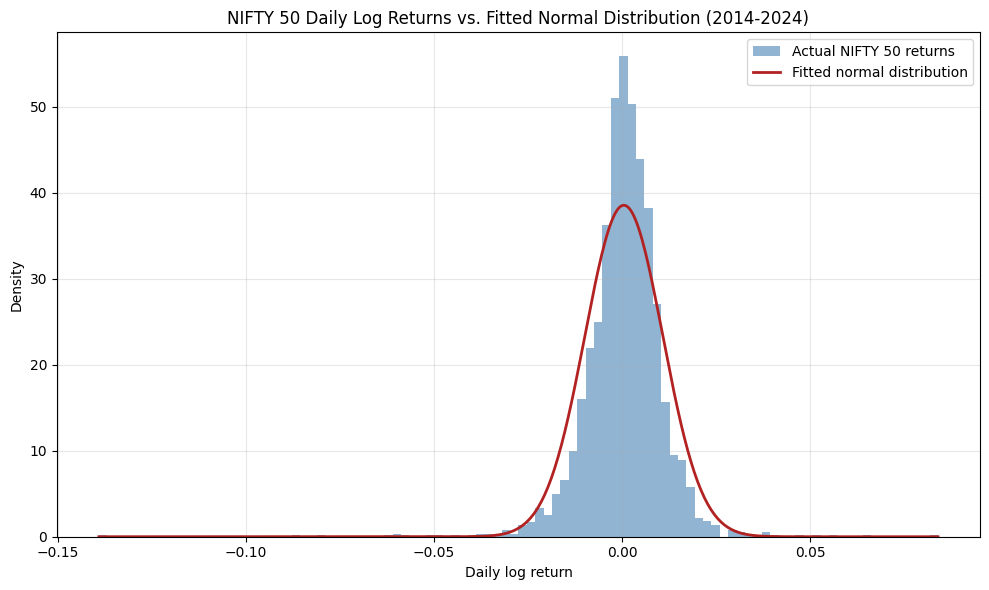

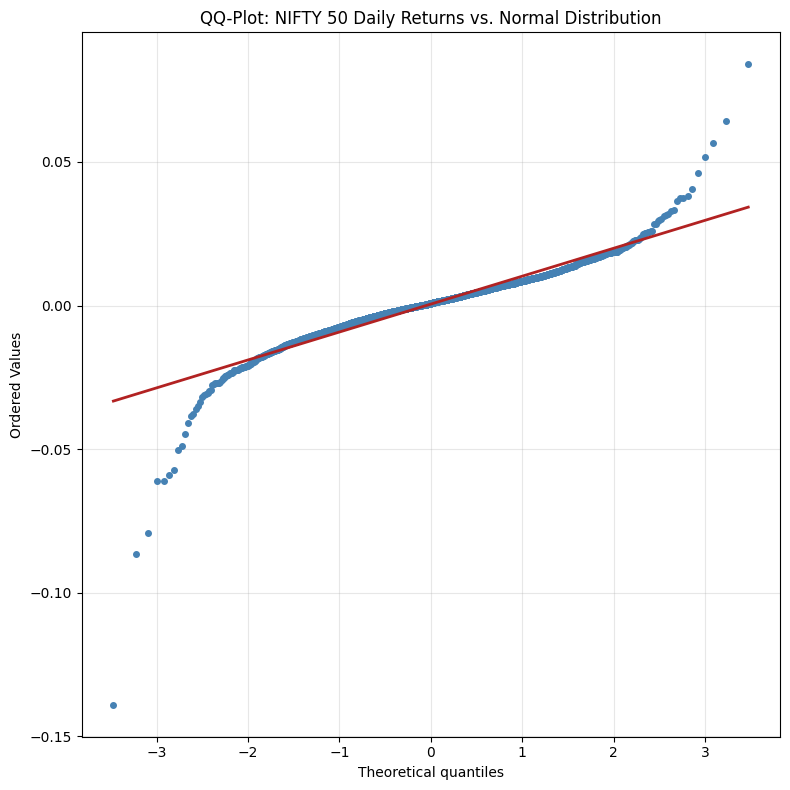

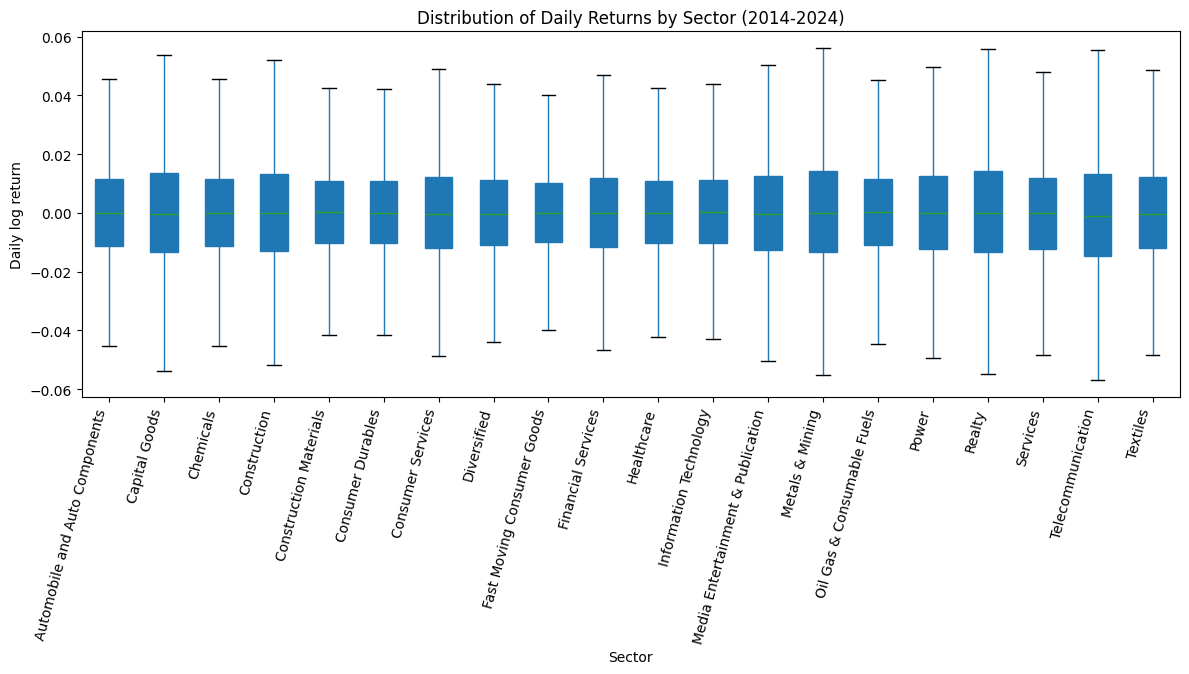

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

nifty_returns = df_clean[df_clean["ticker"] == "NIFTY_50"]["log_return"].dropna()

mu, sigma = nifty_returns.mean(), nifty_returns.std()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(nifty_returns, bins=100, density=True, alpha=0.6, color="steelblue", label="Actual NIFTY 50 returns")

x = np.linspace(nifty_returns.min(), nifty_returns.max(), 500)
ax.plot(x, norm.pdf(x, mu, sigma), color="firebrick", linewidth=2, label="Fitted normal distribution")

ax.set_title("NIFTY 50 Daily Log Returns vs. Fitted Normal Distribution (2014-2024)")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "nifty50_return_histogram.png"), dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
stats.probplot(nifty_returns, dist="norm", plot=ax)

ax.get_lines()[0].set_markerfacecolor("steelblue")
ax.get_lines()[0].set_markeredgecolor("steelblue")
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color("firebrick")
ax.get_lines()[1].set_linewidth(2)

ax.set_title("QQ-Plot: NIFTY 50 Daily Returns vs. Normal Distribution")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "nifty50_qqplot.png"), dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))

sector_order = sector_returns_clean.groupby("sector")["log_return"].median().sort_values(ascending=False).index

sector_returns_clean.boxplot(
    column="log_return",
    by="sector",
    ax=ax,
    showfliers=False,
    patch_artist=True,
    grid=False
)

plt.suptitle("")
ax.set_title("Distribution of Daily Returns by Sector (2014-2024)")
ax.set_xlabel("Sector")
ax.set_ylabel("Daily log return")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "sector_return_boxplot.png"), dpi=150)
plt.show()

In [ ]:
#Heatmap of Top 20 stocks by markt cap
top_20_tickers = pd.read_sql("""
    SELECT ticker FROM stock_metadata
    WHERE market_cap_band = 'Large'
    LIMIT 20
""", conn)["ticker"].tolist()

top_20_prices = df_clean[df_clean["ticker"].isin(top_20_tickers)][["ticker", "date", "adj_close"]].copy()

monthly_prices = top_20_prices.set_index("date").groupby("ticker")["adj_close"].resample("M").last().reset_index()
monthly_returns_wide = monthly_prices.pivot(index="date", columns="ticker", values="adj_close").pct_change()

corr_matrix = monthly_returns_wide.corr()
corr_matrix.head()

/tmp/ipykernel_1702/164989092.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = top_20_prices.set_index("date").groupby("ticker")["adj_close"].resample("M").last().reset_index()


ticker,360ONE,3MINDIA,AADHARHFC,AARTIIND,AAVAS,ABB,ABBOTINDIA,ACC,ACE,ACUTAAS,ADANIENSOL,ADANIENT,ADANIGREEN,ADANIPORTS,ADANIPOWER,AIAENG,APLAPOLLO,ATGL,AUBANK,AWL
ticker,,,,,,,,,,,,,,,,,,,,
360ONE,1.000000,0.424469,0.433552,0.320353,0.469861,0.270436,0.066740,0.362428,0.376461,0.021601,0.346993,0.269289,0.134206,0.352793,0.125142,0.122815,0.146362,0.272491,0.554910,0.314264
3MINDIA,0.424469,1.000000,0.401379,0.252712,0.316291,0.145597,0.069780,0.317054,0.211509,0.032507,0.253214,0.262600,0.249576,0.295673,0.142302,0.260102,0.165183,0.377560,0.330865,-0.078319
AADHARHFC,0.433552,0.401379,1.000000,0.706243,0.478190,0.324636,-0.129743,0.965368,0.409409,0.471129,0.309144,0.320441,0.423865,0.489762,0.813422,0.753204,0.699525,-0.179929,0.373700,-0.373713
AARTIIND,0.320353,0.252712,0.706243,1.000000,0.285411,0.085363,0.290567,0.421350,0.306677,0.209211,0.300284,0.216390,0.201311,0.408596,0.231122,0.325438,0.371090,0.373873,0.311502,0.175950
AAVAS,0.469861,0.316291,0.478190,0.285411,1.000000,0.402394,-0.073955,0.287488,0.262156,0.045610,0.236671,0.213332,0.118052,0.292157,0.175263,0.155108,0.408129,0.232971,0.551580,-0.054371


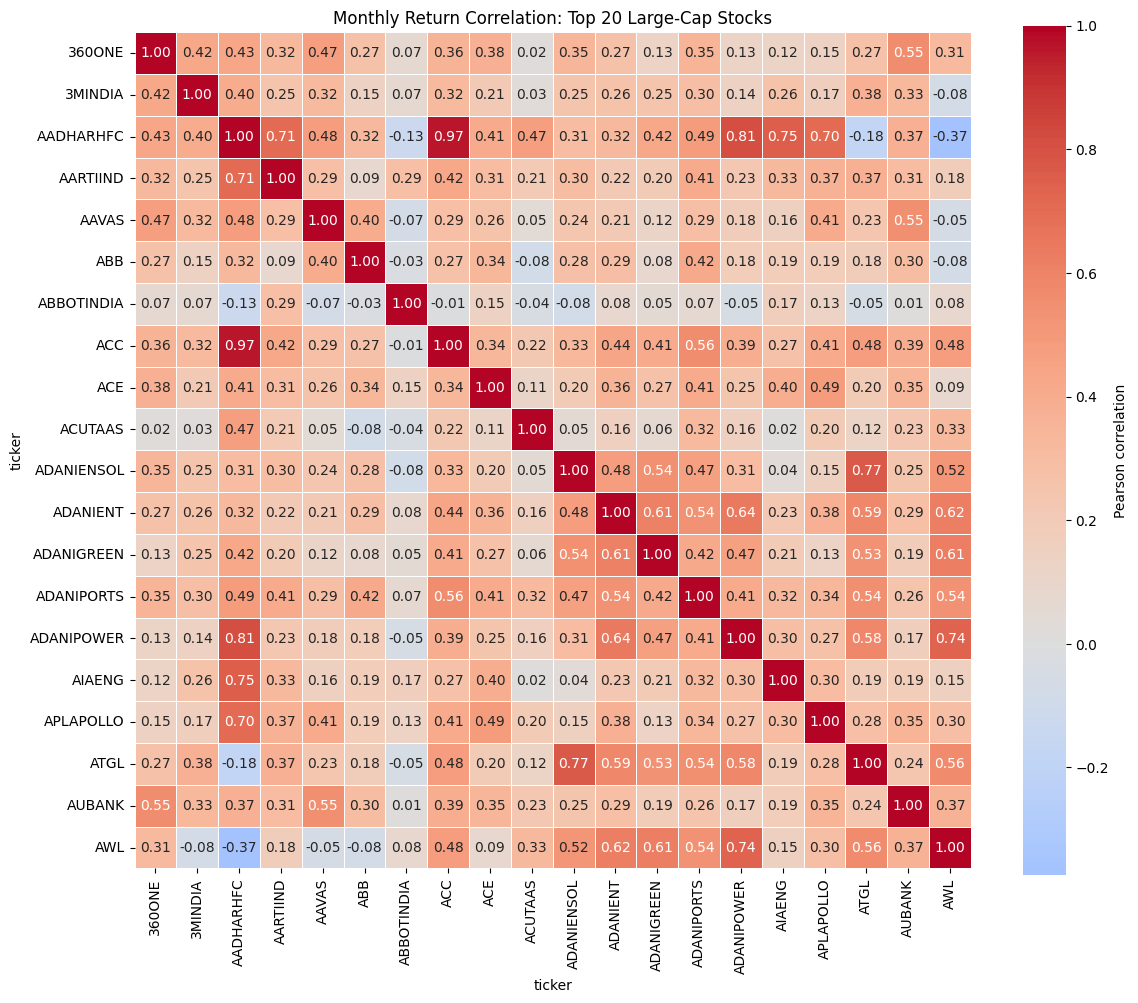

Saved. Verifying...
True


In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Pearson correlation"}
)
ax.set_title("Monthly Return Correlation: Top 20 Large-Cap Stocks")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "correlation_heatmap_top20.png"), dpi=150)
plt.show()

print("Saved. Verifying...")
print(os.path.exists(os.path.join(CHARTS_DIR, "correlation_heatmap_top20.png")))

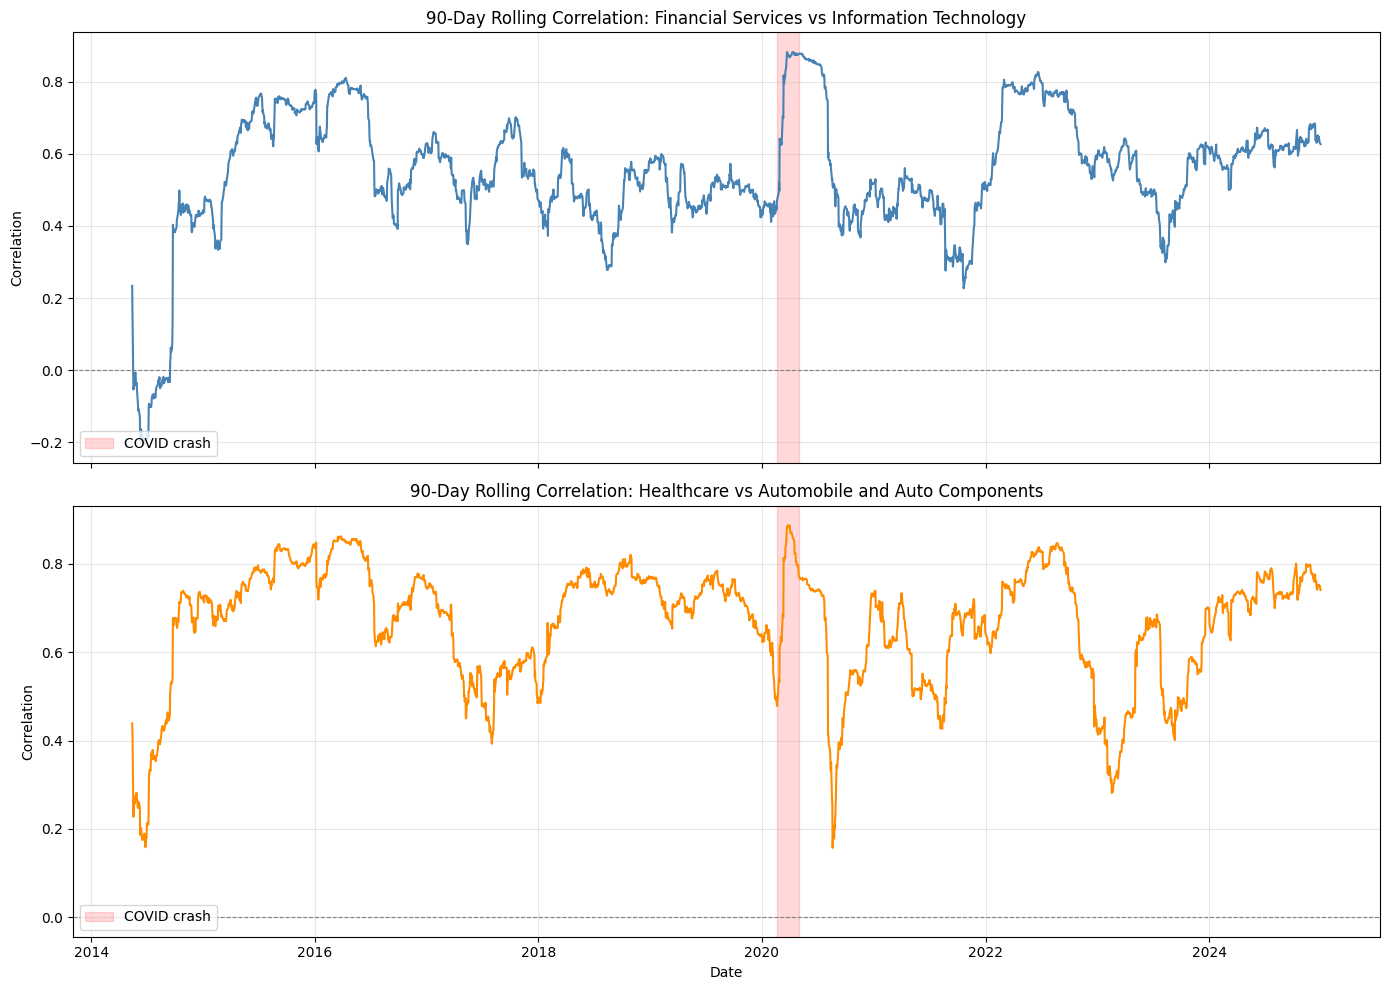

In [ ]:
def get_sector_daily_returns(sector_name):
    sector_data = sector_returns_clean[sector_returns_clean["sector"] == sector_name]
    daily_avg = sector_data.groupby("date")["return_1d"].mean()
    return daily_avg

bank_returns = get_sector_daily_returns("Financial Services")
it_returns = get_sector_daily_returns("Information Technology")
pharma_returns = get_sector_daily_returns("Healthcare")
auto_returns = get_sector_daily_returns("Automobile and Auto Components")

pair_1 = pd.DataFrame({"bank": bank_returns, "it": it_returns}).dropna()
pair_2 = pd.DataFrame({"pharma": pharma_returns, "auto": auto_returns}).dropna()

rolling_corr_1 = pair_1["bank"].rolling(90).corr(pair_1["it"])
rolling_corr_2 = pair_2["pharma"].rolling(90).corr(pair_2["auto"])

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(rolling_corr_1.index, rolling_corr_1.values, color="steelblue")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[0].set_title("90-Day Rolling Correlation: Financial Services vs Information Technology")
axes[0].set_ylabel("Correlation")
axes[0].grid(alpha=0.3)
axes[0].axvspan(pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30"), color="red", alpha=0.15, label="COVID crash")
axes[0].legend(loc="lower left")

axes[1].plot(rolling_corr_2.index, rolling_corr_2.values, color="darkorange")
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_title("90-Day Rolling Correlation: Healthcare vs Automobile and Auto Components")
axes[1].set_ylabel("Correlation")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)
axes[1].axvspan(pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30"), color="red", alpha=0.15, label="COVID crash")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "rolling_sector_correlation.png"), dpi=150)
plt.show()

In [ ]:
nifty = df_clean[df_clean["ticker"] == "NIFTY_50"].copy().sort_values("date").reset_index(drop=True)

nifty["vol_21d"] = nifty["log_return"].rolling(21).std() * np.sqrt(252) * 100

nifty["vol_regime"] = pd.cut(
    nifty["vol_21d"],
    bins=[0, 12, 20, 100],
    labels=["Low", "Medium", "High"]
)

nifty[["date", "vol_21d", "vol_regime"]].dropna().head(10)

,date,vol_21d,vol_regime
21,2014-01-31,12.722338,Medium
22,2014-02-03,13.555029,Medium
23,2014-02-04,13.552139,Medium
24,2014-02-05,13.607256,Medium
25,2014-02-06,13.616349,Medium
26,2014-02-07,13.750352,Medium
27,2014-02-10,13.744243,Medium
28,2014-02-11,12.291253,Medium
29,2014-02-12,12.352158,Medium
30,2014-02-13,12.004146,Medium


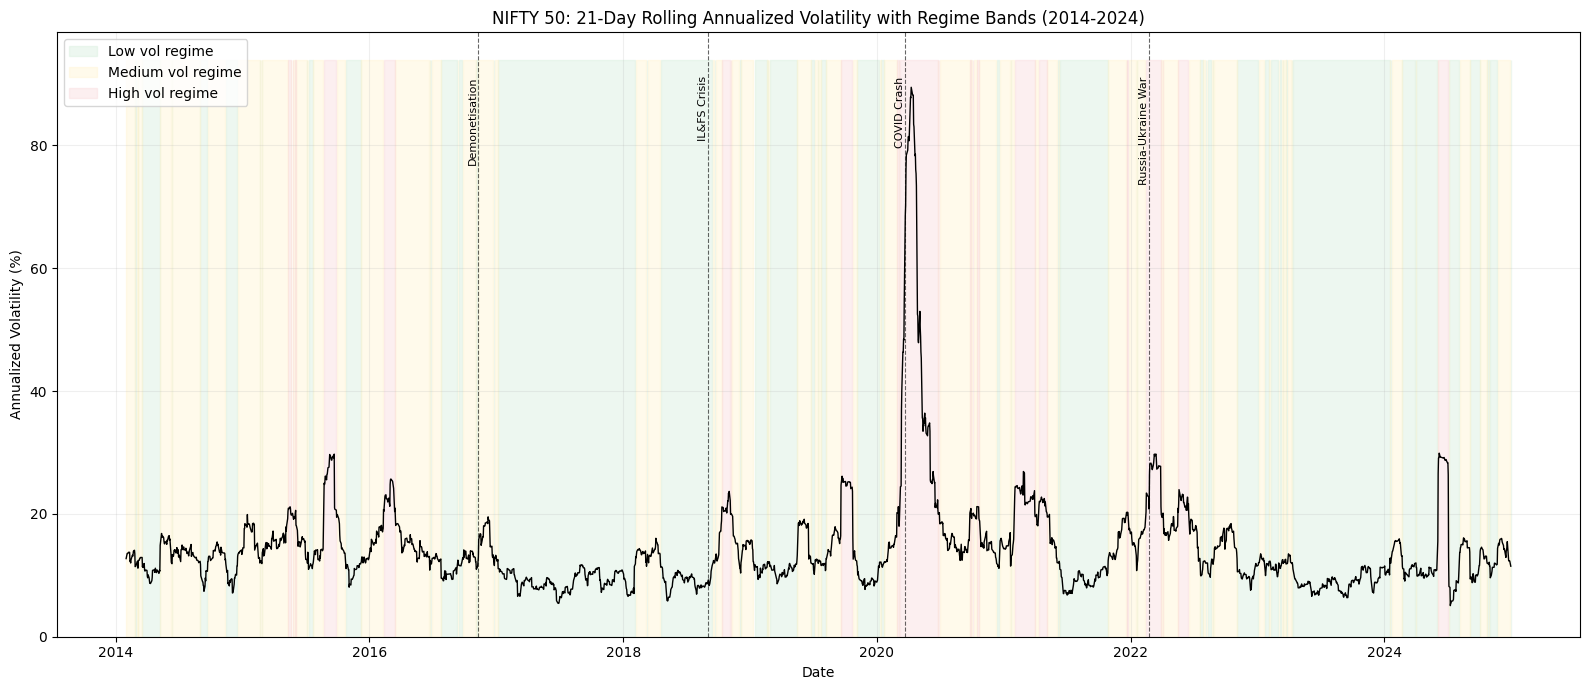

In [ ]:
nifty_plot = nifty.dropna(subset=["vol_21d"]).copy()

fig, ax = plt.subplots(figsize=(16, 7))

regime_colors = {"Low": "#d4edda", "Medium": "#fff3cd", "High": "#f8d7da"}

for regime, color in regime_colors.items():
    mask = nifty_plot["vol_regime"] == regime
    ax.fill_between(nifty_plot["date"], 0, nifty_plot["vol_21d"].max() * 1.05,
                     where=mask, color=color, alpha=0.4, label=f"{regime} vol regime")

ax.plot(nifty_plot["date"], nifty_plot["vol_21d"], color="black", linewidth=1)

events = {
    "2016-11-08": "Demonetisation",
    "2018-09-01": "IL&FS Crisis",
    "2020-03-23": "COVID Crash",
    "2022-02-24": "Russia-Ukraine War",
}

for date_str, label in events.items():
    event_date = pd.Timestamp(date_str)
    ax.axvline(event_date, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(event_date, nifty_plot["vol_21d"].max() * 1.02, label,
            rotation=90, fontsize=8, ha="right", va="top")

ax.set_title("NIFTY 50: 21-Day Rolling Annualized Volatility with Regime Bands (2014-2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility (%)")
ax.set_ylim(0, nifty_plot["vol_21d"].max() * 1.1)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left")

ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "volatility_regime_chart.png"), dpi=150)
plt.show()

In [ ]:
spike_2024 = nifty_plot[nifty_plot["vol_21d"] > 25][["date", "vol_21d"]].sort_values("date")
spike_2024[spike_2024["date"] > "2023-06-01"]

,date,vol_21d
2555,2024-06-04,26.563506
2556,2024-06-05,29.104044
2557,2024-06-06,29.140389
2558,2024-06-07,29.885728
2559,2024-06-10,29.225336
2560,2024-06-11,29.230787
2561,2024-06-12,29.230549
2562,2024-06-13,29.216887
2563,2024-06-14,29.193131
2564,2024-06-18,29.103272


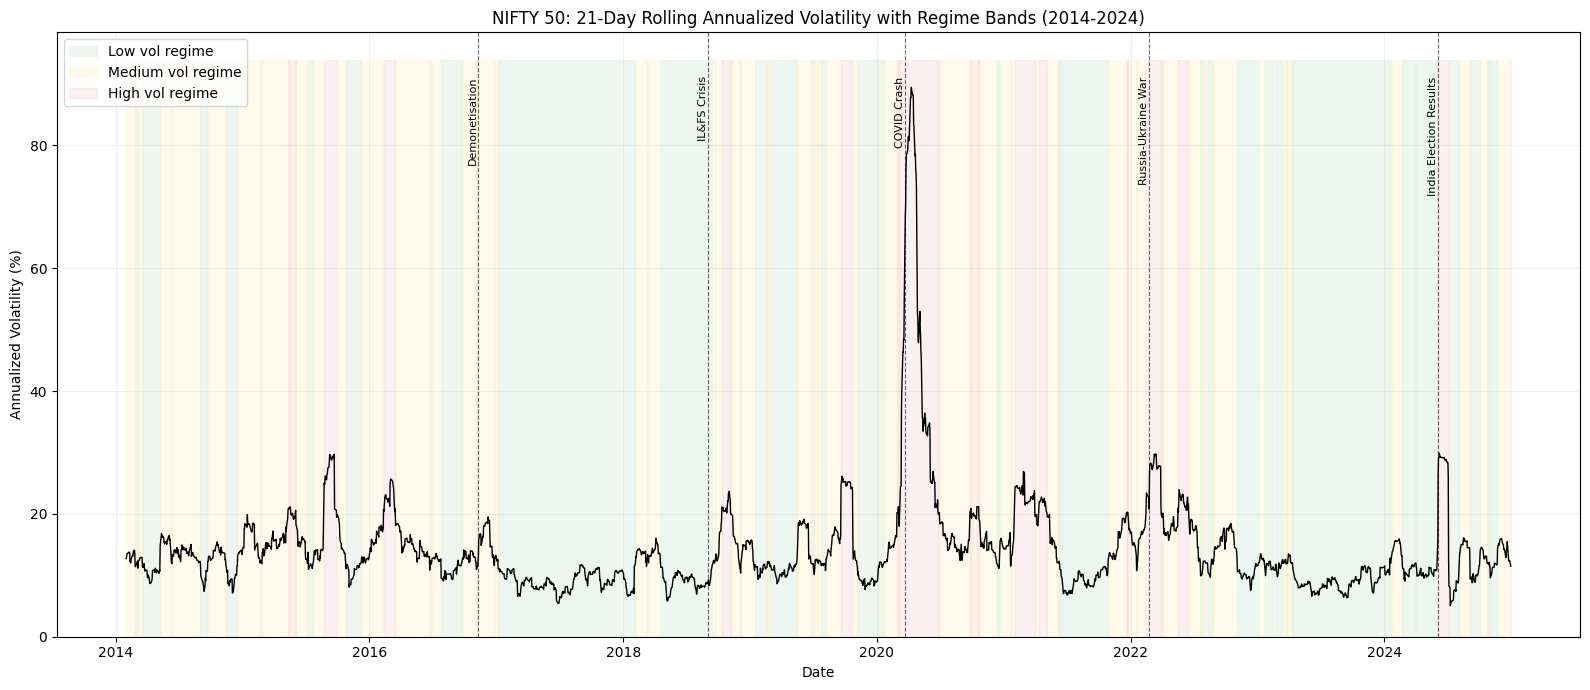

In [ ]:
events = {
    "2016-11-08": "Demonetisation",
    "2018-09-01": "IL&FS Crisis",
    "2020-03-23": "COVID Crash",
    "2022-02-24": "Russia-Ukraine War",
    "2024-06-04": "India Election Results",
}

fig, ax = plt.subplots(figsize=(16, 7))

regime_colors = {"Low": "#d4edda", "Medium": "#fff3cd", "High": "#f8d7da"}

for regime, color in regime_colors.items():
    mask = nifty_plot["vol_regime"] == regime
    ax.fill_between(nifty_plot["date"], 0, nifty_plot["vol_21d"].max() * 1.05,
                     where=mask, color=color, alpha=0.4, label=f"{regime} vol regime")

ax.plot(nifty_plot["date"], nifty_plot["vol_21d"], color="black", linewidth=1)

for date_str, label in events.items():
    event_date = pd.Timestamp(date_str)
    ax.axvline(event_date, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(event_date, nifty_plot["vol_21d"].max() * 1.02, label,
            rotation=90, fontsize=8, ha="right", va="top")

ax.set_title("NIFTY 50: 21-Day Rolling Annualized Volatility with Regime Bands (2014-2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility (%)")
ax.set_ylim(0, nifty_plot["vol_21d"].max() * 1.1)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left")

ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "volatility_regime_chart.png"), dpi=150)
plt.show()

In [ ]:
nifty_dd = nifty_plot[["date", "adj_close"]].copy().reset_index(drop=True)
nifty_dd["running_peak"] = nifty_dd["adj_close"].cummax()
nifty_dd["drawdown"] = (nifty_dd["adj_close"] / nifty_dd["running_peak"] - 1) * 100

nifty_dd.head()

,date,adj_close,running_peak,drawdown
0,2014-01-31,6089.500000,6089.5,0.000000
1,2014-02-03,6001.799805,6089.5,-1.440187
2,2014-02-04,6000.899902,6089.5,-1.454965
3,2014-02-05,6022.399902,6089.5,-1.101898
4,2014-02-06,6036.299805,6089.5,-0.873638


In [ ]:
nifty_dd = df_clean[df_clean["ticker"] == "NIFTY_50"][["date", "adj_close"]].copy()
nifty_dd = nifty_dd.sort_values("date").reset_index(drop=True)
nifty_dd["running_peak"] = nifty_dd["adj_close"].cummax()
nifty_dd["drawdown"] = (nifty_dd["adj_close"] / nifty_dd["running_peak"] - 1) * 100

nifty_dd.head()

,date,adj_close,running_peak,drawdown
0,2014-01-02,6221.149902,6221.149902,0.000000
1,2014-01-03,6211.149902,6221.149902,-0.160742
2,2014-01-06,6191.450195,6221.149902,-0.477399
3,2014-01-07,6162.250000,6221.149902,-0.946769
4,2014-01-08,6174.600098,6221.149902,-0.748251


In [ ]:
def find_drawdown_periods(dd_df):
    periods = []
    in_drawdown = False
    start_idx = None
    trough_idx = None
    trough_value = 0

    for i in range(len(dd_df)):
        dd = dd_df.loc[i, "drawdown"]

        if dd < 0 and not in_drawdown:
            in_drawdown = True
            start_idx = i
            trough_idx = i
            trough_value = dd
        elif dd < 0 and in_drawdown:
            if dd < trough_value:
                trough_value = dd
                trough_idx = i
        elif dd >= 0 and in_drawdown:
            periods.append({
                "start_date": dd_df.loc[start_idx, "date"],
                "trough_date": dd_df.loc[trough_idx, "date"],
                "recovery_date": dd_df.loc[i, "date"],
                "depth_pct": round(trough_value, 2),
                "duration_days": (dd_df.loc[i, "date"] - dd_df.loc[start_idx, "date"]).days
            })
            in_drawdown = False

    return pd.DataFrame(periods)

drawdown_periods = find_drawdown_periods(nifty_dd)
worst_5 = drawdown_periods.sort_values("depth_pct").head(5)
worst_5

,start_date,trough_date,recovery_date,depth_pct,duration_days
66,2020-01-15,2020-03-23,2020-11-09,-38.44,299
26,2015-03-04,2016-02-25,2017-03-14,-22.52,741
91,2021-10-19,2022-06-17,2022-11-24,-17.23,401
57,2018-08-29,2018-10-26,2019-04-16,-14.55,230
62,2019-06-04,2019-09-19,2019-11-27,-11.45,176


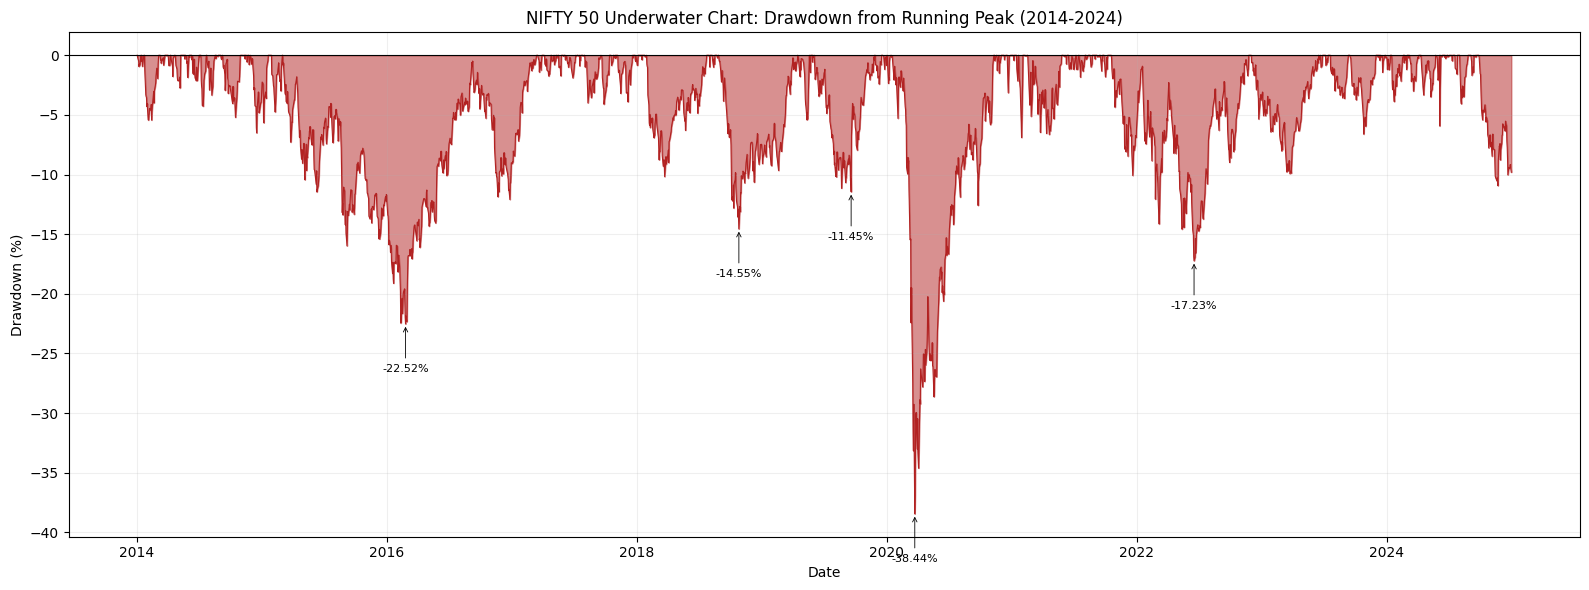

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(nifty_dd["date"], nifty_dd["drawdown"], 0, color="firebrick", alpha=0.5)
ax.plot(nifty_dd["date"], nifty_dd["drawdown"], color="firebrick", linewidth=0.8)

for _, row in worst_5.iterrows():
    ax.annotate(
        f"{row['depth_pct']}%",
        xy=(row["trough_date"], row["depth_pct"]),
        xytext=(row["trough_date"], row["depth_pct"] - 4),
        fontsize=8, ha="center",
        arrowprops=dict(arrowstyle="->", lw=0.6)
    )

ax.set_title("NIFTY 50 Underwater Chart: Drawdown from Running Peak (2014-2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "underwater_chart.png"), dpi=150)
plt.show()

In [ ]:
top_10_for_var = pd.read_sql("""
    SELECT ticker FROM stock_metadata
    WHERE market_cap_band = 'Large'
    LIMIT 10
""", conn)["ticker"].tolist()

portfolio_data = df_clean[df_clean["ticker"].isin(top_10_for_var)][["ticker", "date", "return_1d"]].copy()

portfolio_returns = portfolio_data.groupby("date")["return_1d"].mean().dropna()

print(f"Portfolio observations: {len(portfolio_returns)}")
portfolio_returns.describe()

Portfolio observations: 2709


,return_1d
count,2709.000000
mean,0.001179
std,0.011784
min,-0.110518
25%,-0.005281
50%,0.001463
75%,0.007823
max,0.051976


In [ ]:
var_95 = np.percentile(portfolio_returns, 5)
var_99 = np.percentile(portfolio_returns, 1)
cvar_95 = portfolio_returns[portfolio_returns <= var_95].mean()
cvar_99 = portfolio_returns[portfolio_returns <= var_99].mean()

print(f"VaR 95%: {var_95*100:.2f}%")
print(f"VaR 99%: {var_99*100:.2f}%")
print(f"CVaR 95%: {cvar_95*100:.2f}%")
print(f"CVaR 99%: {cvar_99*100:.2f}%")

VaR 95%: -1.73%
VaR 99%: -3.17%
CVaR 95%: -2.67%
CVaR 99%: -4.51%


Backtest period: 2021-12-31 to 2024-12-30
Total days: 739
Breaches: 40
Breach rate: 5.41% (expected: ~5%)


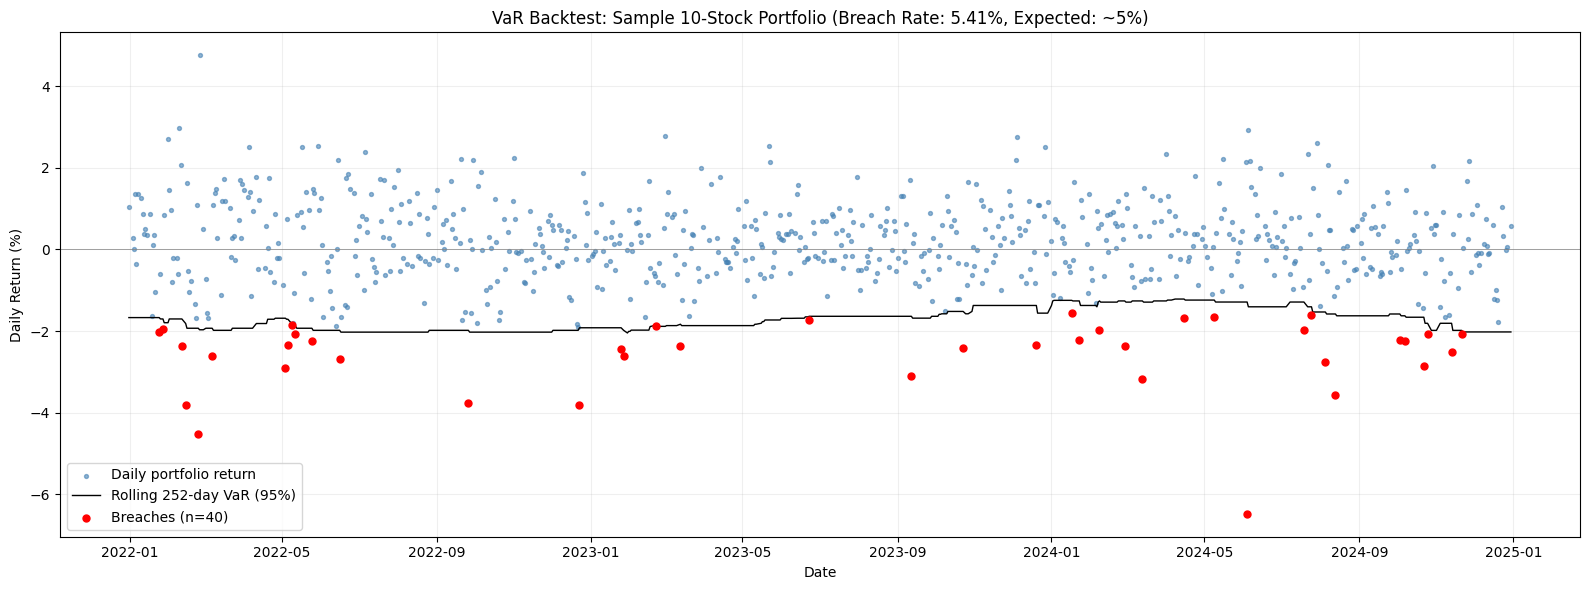

In [ ]:
def rolling_var_backtest(returns, window=252, confidence=0.95):
    results = []
    for i in range(window, len(returns)):
        trailing_window = returns.iloc[i-window:i]
        var_threshold = np.percentile(trailing_window, (1 - confidence) * 100)
        actual_return = returns.iloc[i]
        results.append({
            "date": returns.index[i],
            "actual_return": actual_return,
            "var_threshold": var_threshold,
            "breach": actual_return < var_threshold
        })
    return pd.DataFrame(results)

backtest_full = rolling_var_backtest(portfolio_returns, window=252, confidence=0.95)

backtest_recent = backtest_full[backtest_full["date"] >= backtest_full["date"].max() - pd.Timedelta(days=3*365)]

breach_rate = backtest_recent["breach"].mean() * 100
print(f"Backtest period: {backtest_recent['date'].min().date()} to {backtest_recent['date'].max().date()}")
print(f"Total days: {len(backtest_recent)}")
print(f"Breaches: {backtest_recent['breach'].sum()}")
print(f"Breach rate: {breach_rate:.2f}% (expected: ~5%)")

fig, ax = plt.subplots(figsize=(16, 6))

ax.scatter(backtest_recent["date"], backtest_recent["actual_return"] * 100,
           s=8, color="steelblue", alpha=0.6, label="Daily portfolio return")
ax.plot(backtest_recent["date"], backtest_recent["var_threshold"] * 100,
        color="black", linewidth=1, label="Rolling 252-day VaR (95%)")

breaches = backtest_recent[backtest_recent["breach"]]
ax.scatter(breaches["date"], breaches["actual_return"] * 100,
           s=25, color="red", zorder=5, label=f"Breaches (n={len(breaches)})")

ax.set_title(f"VaR Backtest: Sample 10-Stock Portfolio (Breach Rate: {breach_rate:.2f}%, Expected: ~5%)")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")
ax.axhline(0, color="gray", linewidth=0.5)
ax.legend(loc="lower left")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "var_backtest.png"), dpi=150)
plt.show()

In [ ]:
worst_breach = backtest_recent.sort_values("actual_return").head(3)
worst_breach

,date,actual_return,var_threshold,breach
2314,2024-06-04,-0.064772,-0.012896,True
1756,2022-02-24,-0.045196,-0.019318,True
1961,2022-12-23,-0.038158,-0.019203,True


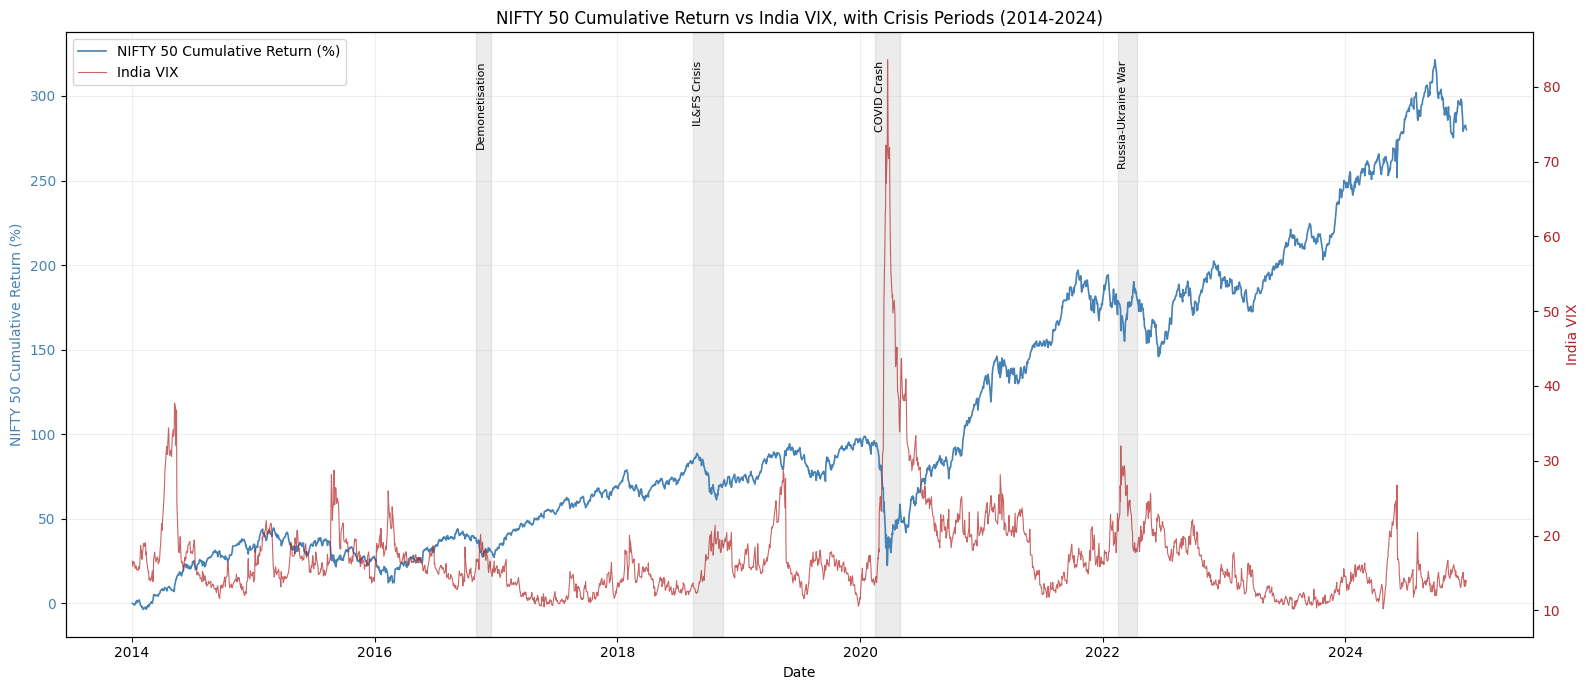

In [ ]:
nifty_full = df_clean[df_clean["ticker"] == "NIFTY_50"][["date", "adj_close"]].copy().sort_values("date").reset_index(drop=True)
nifty_full["cumulative_return"] = (nifty_full["adj_close"] / nifty_full["adj_close"].iloc[0] - 1) * 100

vix_full = pd.read_sql("SELECT date, vix_close FROM india_vix ORDER BY date", conn)
vix_full["date"] = pd.to_datetime(vix_full["date"])

merged = nifty_full.merge(vix_full, on="date", how="inner")
merged.head()

fig, ax1 = plt.subplots(figsize=(16, 7))

ax1.plot(merged["date"], merged["cumulative_return"], color="steelblue", linewidth=1.2, label="NIFTY 50 Cumulative Return (%)")
ax1.set_xlabel("Date")
ax1.set_ylabel("NIFTY 50 Cumulative Return (%)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["vix_close"], color="firebrick", linewidth=0.8, alpha=0.7, label="India VIX")
ax2.set_ylabel("India VIX", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

crisis_periods = [
    ("2016-11-01", "2016-12-15", "Demonetisation"),
    ("2018-08-15", "2018-11-15", "IL&FS Crisis"),
    ("2020-02-15", "2020-04-30", "COVID Crash"),
    ("2022-02-15", "2022-04-15", "Russia-Ukraine War"),
]

for start, end, label in crisis_periods:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="gray", alpha=0.15)
    ax1.text(pd.Timestamp(start), ax1.get_ylim()[1] * 0.95, label, fontsize=8, rotation=90, va="top")

ax1.set_title("NIFTY 50 Cumulative Return vs India VIX, with Crisis Periods (2014-2024)")
ax1.grid(alpha=0.2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "macro_overlay_chart.png"), dpi=150)
plt.show()

In [ ]:
vix_near_zero = merged[merged["vix_close"] < 5][["date", "vix_close"]]
vix_near_zero


,date,vix_close


In [ ]:

fed_data = pd.read_sql("SELECT date, fed_funds_rate FROM macro_indicators ORDER BY date", conn)
fed_data["date"] = pd.to_datetime(fed_data["date"])
fed_data["fed_change"] = fed_data["fed_funds_rate"].diff()

fed_data["fed_regime"] = pd.cut(
    fed_data["fed_change"],
    bins=[-100, -0.01, 0.01, 100],
    labels=["Cutting", "Holding", "Hiking"]
)

nifty_monthly = nifty_full.set_index("date")["adj_close"].resample("M").last()
nifty_monthly_ret = nifty_monthly.pct_change()

fed_data["month"] = fed_data["date"].dt.to_period("M")
nifty_monthly_ret_df = nifty_monthly_ret.reset_index()
nifty_monthly_ret_df["month"] = nifty_monthly_ret_df["date"].dt.to_period("M")

fed_merged = fed_data.merge(nifty_monthly_ret_df[["month", "adj_close"]], on="month", how="inner")
fed_merged = fed_merged.rename(columns={"adj_close": "nifty_monthly_return"})

regime_returns = fed_merged.groupby("fed_regime")["nifty_monthly_return"].agg(["mean", "count"])
regime_returns["mean_pct"] = regime_returns["mean"] * 100
regime_returns


/tmp/ipykernel_1702/325978378.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  nifty_monthly = nifty_full.set_index("date")["adj_close"].resample("M").last()
/tmp/ipykernel_1702/325978378.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_returns = fed_merged.groupby("fed_regime")["nifty_monthly_return"].agg(["mean", "count"])


,mean,count,mean_pct
fed_regime,,,
Cutting,0.010588,19,1.058761
Holding,0.018000,53,1.800047
Hiking,0.005920,59,0.592016


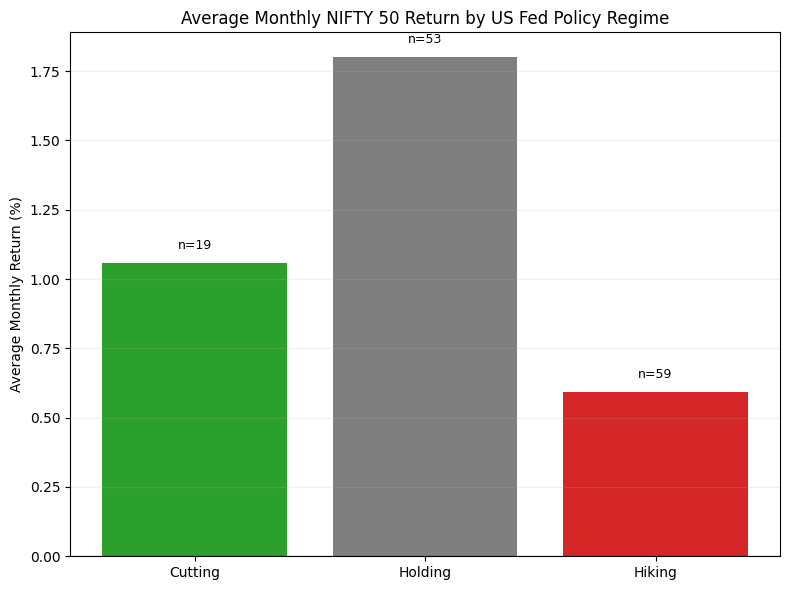

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Cutting": "#2ca02c", "Holding": "#7f7f7f", "Hiking": "#d62728"}
bars = ax.bar(regime_returns.index.astype(str), regime_returns["mean_pct"],
              color=[colors[r] for r in regime_returns.index])

for bar, count in zip(bars, regime_returns["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"n={int(count)}", ha="center", fontsize=9)

ax.set_title("Average Monthly NIFTY 50 Return by US Fed Policy Regime")
ax.set_ylabel("Average Monthly Return (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fed_regime_comparison.png"), dpi=150)
plt.show()

In [ ]:
cutting_months = fed_merged[fed_merged["fed_regime"] == "Cutting"][["month", "nifty_monthly_return"]].sort_values("month")
cutting_months

,month,nifty_monthly_return
6,2014-07,0.014445
21,2015-10,0.014706
26,2016-03,0.107535
44,2017-09,-0.013037
64,2019-05,0.014866
65,2019-06,-0.011235
67,2019-08,-0.008522
68,2019-09,0.040932
69,2019-10,0.035122
70,2019-11,0.015037


In [ ]:
cutting_excl_covid = fed_merged[(fed_merged["fed_regime"] == "Cutting") & (fed_merged["month"] != "2020-03")]
print(f"Cutting regime average WITHOUT March 2020: {cutting_excl_covid['nifty_monthly_return'].mean()*100:.2f}%")
print(f"Cutting regime average WITH March 2020 (original): {regime_returns.loc['Cutting', 'mean_pct']:.2f}%")

Cutting regime average WITHOUT March 2020: 2.41%
Cutting regime average WITH March 2020 (original): 1.06%


Total charts saved: 10
correlation_heatmap_top20.png
fed_regime_comparison.png
macro_overlay_chart.png
nifty50_qqplot.png
nifty50_return_histogram.png
rolling_sector_correlation.png
sector_return_boxplot.png
underwater_chart.png
var_backtest.png
volatility_regime_chart.png


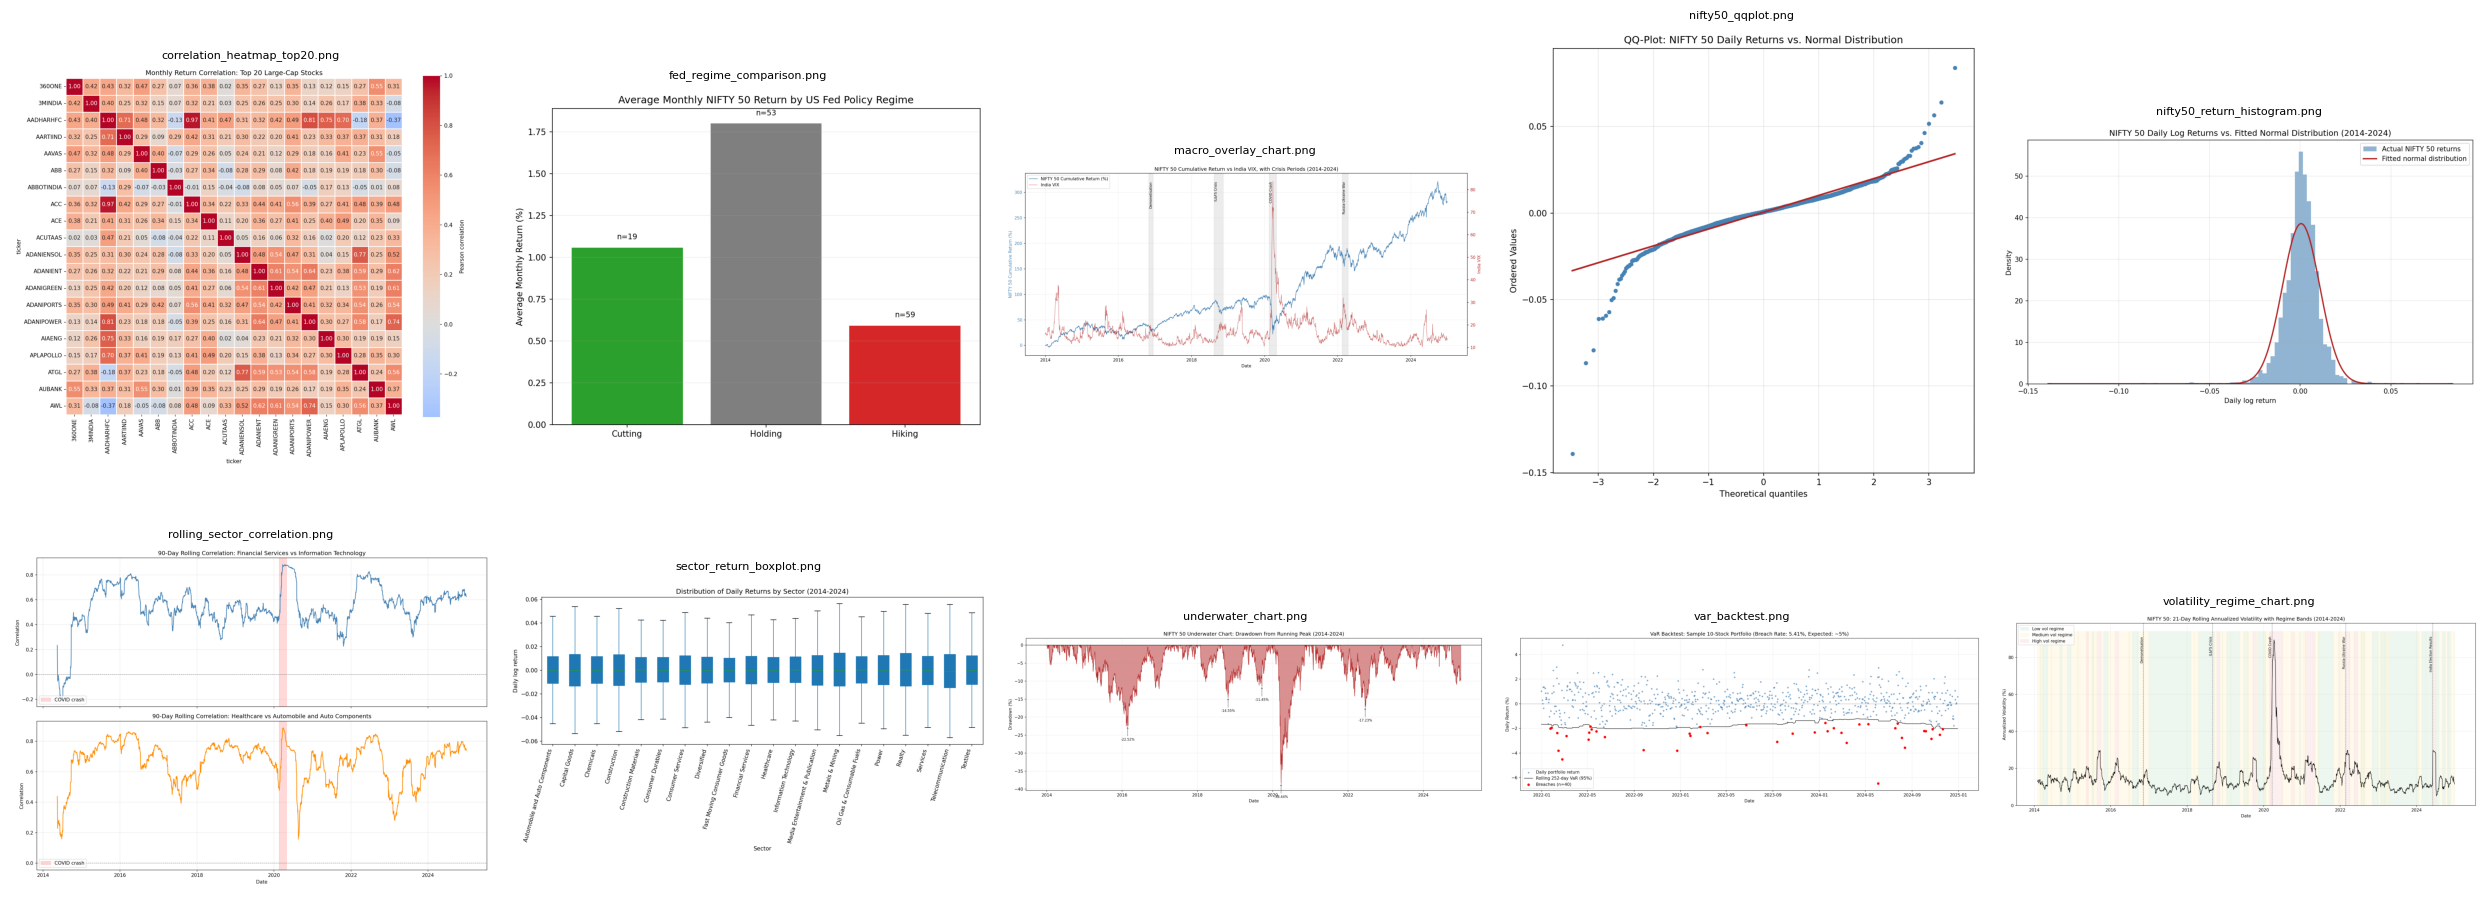

In [ ]:
chart_files = sorted(os.listdir(CHARTS_DIR))
print(f"Total charts saved: {len(chart_files)}")
for f in chart_files:
    print(f)
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, fname in enumerate(chart_files[:10]):
    img = plt.imread(os.path.join(CHARTS_DIR, fname))
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(fname, fontsize=8)

plt.tight_layout()
plt.show()